# XAI METHODS APPLICATION with B-XAIC (Task X and Task PAINS) - GIN


# SETUP:

In [1]:
# Cloning the repository to access the code and data of B-XAIC, which is the framework we are using for our XAI methods.
!git clone https://github.com/mproszewska/B-XAIC.git

# Change the current working directory to B-XAIC to be able to run the code and access the data.
%cd B-XAIC

fatal: destination path 'B-XAIC' already exists and is not an empty directory.
/Users/lucaderuggiero/Desktop/Progetto_XAIC/B-XAIC


In [ ]:
# Install PyTorch Geometric (library for graph neural networks, which we will use for our GAT model and XAI methods)
!pip install torch_geometric

# Install RDKit (the fundamental library for manipulating molecules and SMILES format, which we will use for our GIN model and XAI methods)
!pip install rdkit

# Install Captum (we will use it later for gradient-based methods like Saliency)
!pip install captum

In [2]:
# Cloning the repository to access the code and data of ProtGNN
%cd libs
!git clone https://github.com/zaixizhang/ProtGNN
%cd ..

/Users/lucaderuggiero/Desktop/Progetto_XAIC/B-XAIC/libs
fatal: destination path 'ProtGNN' already exists and is not an empty directory.
/Users/lucaderuggiero/Desktop/Progetto_XAIC/B-XAIC


In [ ]:
from huggingface_hub import hf_hub_download
import os

# 1. Create a "data" directory if it doesn't exist to store the downloaded files
os.makedirs("data", exist_ok=True)

print("Scaricamento di data.csv in corso...")
# 2. Download the CSV file (which contains the SMILES strings and labels) into the "data" folder
hf_hub_download(
    repo_id="mproszewska/B-XAIC",
    filename="data.csv",
    repo_type="dataset",
    local_dir="data"
)

print("Scaricamento di explanations.sdf in corso... (potrebbe volerci qualche minuto)")
# 3. Download the SDF file (which contains the explanations in a format that can be visualized on molecules) into the "data" folder
hf_hub_download(
    repo_id="mproszewska/B-XAIC",
    filename="explanations.sdf",
    repo_type="dataset",
    local_dir="data"
)

print("\nFatto! I dati sono stati scaricati e posizionati correttamente per la pipeline.")

In [ ]:
# Installing the geco-explainer library, which we will use for some of the XAI methods in our experiments.

!pip install geco-explainer

In [ ]:
# Installing captum, which we will use for Integrated Gradients explanations.

!pip install captum

In [ ]:
# Installing rdkit and matplotlib, which we will use for visualizing explanations on molecules.

!pip install rdkit matplotlib

# PIPELINE DEL LAVORO:

### XAI Methods We Used:

- **Saliency** -> *Gradient-Based* = Analyzes the gradients (derivatives) of individual features (e.g., "Atom type") with respect to the output. It is almost exclusively focused on Nodes/Features.
- **GNNExplainer** -> *Mask-Based* = Learns two separate masks (one for nodes/features, one for edges) that maximize the Mutual Information with the original prediction. Direct competitor of CausGNN because it analyzes both nodes and edges.
- **ProtGNN + GAT** -> *Prototype-Based, Self-Interpretable* = Compares the target molecule with "Prototypes" (typical examples) seen during training. It selects a subgraph (thus implicitly a set of nodes and edges), but its logic is oriented towards finding the "region" (the node patch) that resembles the prototype. It does not return a continuous score for each individual bond.
- **GECo** -> *Community-Based* = Groups nodes into "communities" (clusters) based on their interactions (often using modularity or spectral methods) and identifies which community drives the prediction. Focused on Nodes.
- **CausGNN** -> *Causal-Based* = Computes the Causal Effect (the drop in probability) by perturbing the variables. CausGNN applies the causality concept $do(X=x)$ by cutting both the node and the edges.

### Evaluation Metrics:

- IQR (for NULL EXPLANATIONS) from the B-XAIC paper
- AUROC (for SUBGRAPH EXPLANATIONS) from the B-XAIC paper
- (Computation time)

### Type of GNN:

- **GIN** = Graph Isomorphism Network

### NOTES:

- DATA ERROR:

The Python library utilized for handling molecules is RDKit. By default, when loading a molecule, RDKit applies a verification procedure known as Sanitization to ensure compliance with chemical laws.

In nature, Phosphorus (P) typically forms 3 or 5 bonds (valency 3 or 5). However, within the downloaded explanations.sdf file, a specific molecule is incorrectly formatted, assigning 7 bonds to a Phosphorus atom.

Due to this chemical inconsistency, RDKit fails to process the molecule and returns a None value to the program.

- ERROR IN THE PyTorch Geometric LIBRARY:

The issue stems from an update in PyTorch Geometric. In older versions, the topk function was located within torch_geometric.utils. In current versions, it has been relocated to torch_geometric.nn.

Since the topk function is imported at the beginning of the script but never actually utilized within the code, the most efficient resolution consists of removing the unused import statement entirely.

- WE ADDED THE GECo MODEL TO THE extract_explanations.py FILE

- NODE AND EDGE EXTRACTION IN RESULTS:

For the halogen task (TASK X), extracting results related to edge masks using GNNExplainer and CausGNN is not feasible, as it is not supported by the inherent nature of the data.

For the PAINS task, however, edge mask extraction is methodologically relevant and will be performed.

# DEBUGGING:

### FUNCTIONS to DEBUG & ADD:

- *dataset.py* from B-XAIC repo (debugged)
- *libs/ProtGNN/models/GCN.py* from B-XAIC repo (debugged)
- *extract_explanations.py* from B-XAIC repo (debugged + added some methods)
- *causgnn_repo_exact.py* (added)
- *train_protgnn.py* from B-XAIC repo (debugged)

In [ ]:
%%writefile dataset.py
import os
import random
from torch_geometric.data import Data, InMemoryDataset
import numpy as np
import pandas as pd
from tqdm import tqdm
from rdkit import Chem
from rdkit.Chem import BondType
from rdkit.Chem import rdFingerprintGenerator
from rdkit import DataStructs

import torch
import torch.nn.functional as F
from torch_geometric.data import Data

from torch_geometric.utils import subgraph

TASKS = ["B", "P", "X", "indole", "PAINS", "rings-count", "rings-max"]
SYMBOLS = ["C", "N", "O", "F", "Cl", "Br", "P", "S", "B", "I", "Unk"]

class XAIMolecularDataset(InMemoryDataset):
    def __init__(self, root, name, explanations=True) -> None:
        self.name = name
        super().__init__(root)
        assert self.name in TASKS
        self.molecular_data_path = f"{root}/data.csv"
        self.explanations_data_path = f"{root}/explanations.sdf"

        self._num_classes = 2
        property = {
            "P": "P",
            "X": "X",
            "B": "B",
            "indole": "indole",
            "PAINS": "pains",
            "rings-count": "rings",
            "rings-max": "largest_rings",
        }[self.name]
        df = pd.read_csv(self.molecular_data_path)
        self.splits = df[[f"split_{i}" for i in range(5)]]

        dataset = list()
        valid_indices = []

        with Chem.SDMolSupplier(self.explanations_data_path) as suppl:
            ys = torch.tensor(df[name].tolist()).unsqueeze(1)

            for i, (y, mol) in tqdm(enumerate(zip(ys, suppl)), total=len(ys)):
                if mol is None:
                    continue

                valid_indices.append(i)

                x, edge_index, edge_attr = smiles_to_graph(mol)
                if explanations:
                    p = mol.GetProp(property)
                    expl_node_mask = torch.zeros(len(x), dtype=torch.bool)
                    if p != "":
                        nodes = p.split(",")
                        nodes = torch.tensor([int(n) for n in nodes], dtype=torch.long)
                        expl_node_mask[nodes] = True
                    if property not in ["B", "P", "X"]:
                        p = mol.GetProp(f"{property}_edge")
                        expl_edge_mask = torch.zeros(edge_index.shape[1], dtype=torch.bool)
                        if p != "":
                            edges = p.split(",")
                            edges = [e.split("#") for e in edges]
                            edges = {(int(e1), int(e2)) for e1, e2 in edges}

                            for j in range(edge_index.shape[1]):
                                e = edge_index[:, j]
                                e1, e2 = e[0].item(), e[1].item()
                                expl_edge_mask[j] = ((e1, e2) in edges) or ((e2, e1) in edges)
                    else:
                        expl_edge_mask = None

                    data = Data(
                        x=x,
                        edge_index=edge_index,
                        edge_attr=edge_attr,
                        y=y,
                        expl_node_mask=expl_node_mask,
                        expl_edge_mask=expl_edge_mask,
                    )
                else:
                    data = Data(x=x, edge_index=edge_index, edge_attr=edge_attr, y=y)
                dataset.append(data)
            self.data_lst = dataset

        self.splits = self.splits.iloc[valid_indices].reset_index(drop=True)
        self._num_node_features = self.__getitem__(0).x.shape[-1]

    @property
    def num_classes(self):
        return self._num_classes

    @property
    def num_node_features(self):
        return self._num_node_features

    def __getitem__(self, idx: int):
        data = self.data_lst[idx]
        return data

    # FIX AGGIUNTO QUI: **kwargs assorbe 'old=True' o qualsiasi altra cosa extra senza crashare
    def get_splits(self, split_idx, **kwargs):
        splits = self.splits[f"split_{split_idx}"]
        idx = torch.arange(len(splits))
        train_idx, val_idx, test_idx = (
            idx[splits == "train"],
            idx[splits == "valid"],
            idx[splits == "test"],
        )
        return train_idx, val_idx, test_idx

    def __len__(self):
        return len(self.data_lst)

def atom_label(atom):
    sym = atom.GetSymbol()
    return SYMBOLS.index(sym) if sym in SYMBOLS else len(SYMBOLS) - 1

def bond_type_to_int(bond_type):
    if bond_type == BondType.SINGLE:
        return 0
    elif bond_type == BondType.DOUBLE:
        return 1
    elif bond_type == BondType.TRIPLE:
        return 2
    elif bond_type == BondType.AROMATIC:
        return 3
    else:
        return -1

def smiles_to_graph(mol):
    node_labels = F.one_hot(
        torch.tensor([atom_label(atom) for atom in mol.GetAtoms()], dtype=torch.long),
        len(SYMBOLS),
    ).float()
    x = node_labels
    row, col = [], []
    edge_labels = []
    for bond in mol.GetBonds():
        i = bond.GetBeginAtomIdx()
        j = bond.GetEndAtomIdx()
        row += [i, j]
        col += [j, i]
        edge_type = bond_type_to_int(bond.GetBondType())
        edge_labels += [
            edge_type,
            edge_type,
        ]
    edge_index = torch.tensor([row, col], dtype=torch.long)
    edge_attr = torch.tensor(edge_labels, dtype=torch.long).view(-1, 1)

    return (x, edge_index, edge_attr)

In [ ]:
# debugging per errore nella libreria di pytorch geometric visto prima

%%writefile libs/ProtGNN/models/GCN.py
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch_geometric.nn import GCNConv, global_max_pool as gmp
# Rimosso topk e dropout_adj che causavano l'ImportError

class GCNNet(nn.Module):
    def __init__(self, num_features, num_classes, args):
        super(GCNNet, self).__init__()
        self.args = args
        self.conv1 = GCNConv(num_features, self.args.hidden_dim)
        self.bn1 = nn.BatchNorm1d(self.args.hidden_dim)
        self.conv2 = GCNConv(self.args.hidden_dim, self.args.hidden_dim)
        self.bn2 = nn.BatchNorm1d(self.args.hidden_dim)
        self.conv3 = GCNConv(self.args.hidden_dim, self.args.hidden_dim)
        self.bn3 = nn.BatchNorm1d(self.args.hidden_dim)
        self.lin = nn.Linear(self.args.hidden_dim * 2, self.args.linear_dim)
        self.lin_out = nn.Linear(self.args.linear_dim, num_classes)

    def forward(self, data):
        x, edge_index, batch = data.x, data.edge_index, data.batch
        edge_attr = getattr(data, 'edge_attr', None)

        x = self.conv1(x, edge_index, edge_attr)
        x = F.relu(x)
        x = self.bn1(x)
        x = F.dropout(x, p=self.args.dropout, training=self.training)

        x = self.conv2(x, edge_index, edge_attr)
        x = F.relu(x)
        x = self.bn2(x)
        x = F.dropout(x, p=self.args.dropout, training=self.training)

        x = self.conv3(x, edge_index, edge_attr)
        x = F.relu(x)
        x = self.bn3(x)
        x = F.dropout(x, p=self.args.dropout, training=self.training)

        # Global pooling
        x = gmp(x, batch)

        # Readout
        x = F.relu(self.lin(x))
        x = F.dropout(x, p=self.args.dropout, training=self.training)
        x = self.lin_out(x)
        return F.log_softmax(x, dim=-1)

class GCNNet_NC(nn.Module):
    def __init__(self, num_features, num_classes, args):
        super(GCNNet_NC, self).__init__()
        self.args = args
        self.conv1 = GCNConv(num_features, self.args.hidden_dim)
        self.bn1 = nn.BatchNorm1d(self.args.hidden_dim)
        self.conv2 = GCNConv(self.args.hidden_dim, self.args.hidden_dim)
        self.bn2 = nn.BatchNorm1d(self.args.hidden_dim)
        self.conv3 = GCNConv(self.args.hidden_dim, self.args.hidden_dim)
        self.bn3 = nn.BatchNorm1d(self.args.hidden_dim)
        self.lin = nn.Linear(self.args.hidden_dim, self.args.linear_dim)
        self.lin_out = nn.Linear(self.args.linear_dim, num_classes)

    def forward(self, data):
        x, edge_index = data.x, data.edge_index
        edge_attr = getattr(data, 'edge_attr', None)

        x = self.conv1(x, edge_index, edge_attr)
        x = F.relu(x)
        x = self.bn1(x)
        x = F.dropout(x, p=self.args.dropout, training=self.training)

        x = self.conv2(x, edge_index, edge_attr)
        x = F.relu(x)
        x = self.bn2(x)
        x = F.dropout(x, p=self.args.dropout, training=self.training)

        x = self.conv3(x, edge_index, edge_attr)
        x = F.relu(x)
        x = self.bn3(x)
        x = F.dropout(x, p=self.args.dropout, training=self.training)

        # No global pooling for node classification

        x = F.relu(self.lin(x))
        x = F.dropout(x, p=self.args.dropout, training=self.training)
        x = self.lin_out(x)
        return F.log_softmax(x, dim=-1)

In [ ]:
%%writefile extract_explanations.py
import argparse
import copy
import json
import os
from tqdm import tqdm

import numpy as np
import pandas as pd
import torch

import torch.nn as nn
import torch.nn.functional as F

from torch.utils.data import Subset

from torch_geometric.data import Data, Batch
from torch_geometric.explain import Explainer, GNNExplainer, PGExplainer
from torch_geometric.loader import DataLoader
from torch_geometric.utils import to_dense_adj, subgraph
from torch_geometric.nn.conv import MessagePassing
from torch_geometric.nn.conv import GINConv

from sklearn.metrics import roc_auc_score

from torch_geometric.explain import (
    Explainer,
    GNNExplainer,
    PGExplainer,
    CaptumExplainer,
    GraphMaskExplainer,
)

from dataset import XAIMolecularDataset
from train_model import get_model, set_seed, test

import sys

sys.path.append(f"{os.getcwd()}/libs/ProtGNN")
from libs.ProtGNN.Configures import model_args
from libs.ProtGNN.models import GnnNets

EXPLAINERS = [
    "GNNExplainer",
    "PGExplainer",
    "IntegratedGradients",
    "ShapleyValueSampling",
    "Saliency",
    "InputXGradient",
    "Deconvolution",
    "GuidedBackprop",
    "GraphMaskExplainer",
    "PGMExplainer",
    "FlowX",
    "SubgraphX",
    "GECo",
    "CausGNN",
    "IntegratedGradients",
]


def args_parser():
    parser = argparse.ArgumentParser(description="")
    parser.add_argument("--seed", type=int, default=123, help="seed")
    parser.add_argument("--trials", type=int, default=1, help="number of trials")
    parser.add_argument("--save_path", type=str, required=True, help="path to save explanations")
    parser.add_argument("--batch_size", type=int, default=32, help="batch size")
    parser.add_argument("--model_path", type=str, required=True, help="model path")
    parser.add_argument(
        "--explainer_type",
        type=str,
        required=True,
        choices=EXPLAINERS,
        help="explainer type",
    )
    parser.add_argument("--explanation_type", type=str, required=True, choices=["phenomenon", "model"])
    parser.add_argument(
        "--node_mask_type",
        type=str,
        required=True,
        choices=["object", "none", "attributes", "common_attributes"],
    )
    parser.add_argument(
        "--edge_mask_type",
        type=str,
        required=True,
        choices=["object", "none", "attributes", "common_attributes"],
    )
    parser.add_argument("--lr", type=float, default=0.001, help="learning rate")
    parser.add_argument("--epochs", type=int, default=200, help="number of epochs")
    parser.add_argument(
        "--n_samples",
        type=int,
        default=5,
        help="n_samples in ShapleyValueSampling",
    )
    parser.add_argument("--perturb", type=str, default="zero", help="perturb")
    parser.add_argument("--save_all", type=bool, default=False)
    args = parser.parse_args()
    return args


class ProtGNNWrapper(torch.nn.Module):
    def __init__(self, model):
        super().__init__()
        self.model = model

    def forward(self, x, edge_index, batch):
        data = Data(x=x, edge_index=edge_index, batch=batch)
        return self.model(data)[0]

class Wrap(nn.Module):
    def __init__(self, model):
        super().__init__()
        self.model = model
    def forward(self, x, edge_index, batch=None):
        return self.model(x, edge_index, batch=batch)

def main():
    args = args_parser()
    if args.node_mask_type == "none":
        args.node_mask_type = None
    if args.edge_mask_type == "none":
        args.edge_mask_type = None
    print(args)
    set_seed(args.seed)

    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

    loaded = torch.load(args.model_path, map_location=torch.device("cpu"), weights_only=False)
    loaded_args = loaded["args"]

    dataset = XAIMolecularDataset("data", loaded_args["task"], explanations=True)
    train_idxs, val_idxs, test_idxs = dataset.get_splits(loaded_args["split"], old=True)

    dataset_train, dataset_val, dataset_test = (
        Subset(dataset, train_idxs),
        Subset(dataset, val_idxs),
        Subset(dataset, test_idxs),
    )

    dataloader_test = DataLoader(dataset_test, batch_size=args.batch_size, shuffle=False)

    try:
        model = get_model(**loaded["model_args"]).to(device)
        model.load_state_dict(loaded["state_dict"])
        num_layers = loaded["model_args"]["num_layers"]
        # Setting up params used by an explainer
        for module in model.modules():
            if isinstance(module, MessagePassing):
                if not hasattr(module, "in_channels"):
                    channel_list = module.nn.channel_list
                    module.in_channels = channel_list[0]
                    module.out_channels = channel_list[-1]
    except Exception as e:
        print(e)
        model_args.model_name = loaded["args"]["model_type"]
        model_args.readout = loaded["args"]["readout"]
        input_dim = dataset.num_node_features
        output_dim = int(dataset.num_classes)
        protgnn = GnnNets(input_dim, output_dim, model_args)
        for layer in protgnn.model.gnn_layers:
            if isinstance(layer, GINConv):
                layer.in_channels = layer.nn[0].in_features
                layer.out_channels = layer.nn[0].out_features
        num_layers = len(protgnn.model.gnn_layers)
        protgnn.load_state_dict(loaded["state_dict"])
        model = ProtGNNWrapper(protgnn.model).to(device)
    model.eval()


    _, f1 = test(model, dataloader_test, device)
    assert np.abs(f1 - loaded["f1"]) < 0.01, f"f1 score: {f1:.2f} != {loaded['f1']:.2f}"
    model_config = dict(mode="multiclass_classification", task_level="graph", return_type="raw")
    if args.explainer_type == "PGExplainer":
        algorithm = PGExplainer(epochs=args.epochs, lr=args.lr).to(device)
    elif args.explainer_type == "GNNExplainer":
        algorithm = GNNExplainer(epochs=args.epochs, lr=args.lr).to(device)
    elif args.explainer_type == "ShapleyValueSampling":
        algorithm = CaptumExplainer("ShapleyValueSampling", n_samples=5)
    elif args.explainer_type == "GraphMaskExplainer":
        algorithm = GraphMaskExplainer(num_layers=num_layers, epochs=args.epochs, lr=args.lr)
    elif args.explainer_type == "PGMExplainer":
        assert args.node_mask_type == "object"
        assert args.edge_mask_type is None
        from torch_geometric.contrib.explain import PGMExplainer
        model_config = dict(mode="multiclass_classification", task_level="graph", return_type="probs")
        wrapper = Wrap(model)
        explainer_config = dict(explanation_type=args.explanation_type, node_mask_type=args.node_mask_type, edge_mask_type=args.edge_mask_type)
        explanations = []
        for data in tqdm(dataset_test):
            explainer = PGMExplainer(perturbation_mode=args.perturb,
                                     num_samples=100,
                                     max_subgraph_size=data.x.shape[0])  # , max_subgraph_size=1)
            explainer.connect(model_config=model_config, explainer_config=explainer_config)

            data = data.to(device)
            explanation = explainer(wrapper, data.x, data.edge_index, target=data.y)
            pred = wrapper(data.x, data.edge_index)
            expl = Data(
                x=data.x.detach().cpu(),
                edge_index=data.edge_index.detach().cpu(),
                y=data.y.detach().cpu(),
                pred=pred.detach().cpu(),
                node_mask=1 - explanation.pgm_stats,
                edge_mask=None,
                gt_node_mask=data.expl_node_mask.detach().cpu() if hasattr(data, "expl_node_mask") else None,
                gt_edge_mask=(
                    data.expl_edge_mask.detach().cpu() if hasattr(data, "expl_edge_mask") else None
                ),
            )
            explanations.append(expl)

        print(f"Finished with {len(explanations)}/{len(dataset_test)} explanations")
        torch.save(
            {
                "args": vars(args),
                "model_args": loaded_args,
                "explanations": explanations,
                "f1": loaded["f1"],
            },
            args.save_path,
        )
        print(f"Saved to {args.save_path}")
        exit(0)

    # --- INIZIO BLOCCO GECO (Incollalo qui sotto) ---
    elif args.explainer_type == "GECo":
        from geco_explainer import GECo
        print("\n[INFO] Avvio estrazione GECo (Community-based XAI)")
        explanations = []

        explainer = GECo(device, model)

        for data in tqdm(dataset_test):
            data = data.to(device)

            # 1. Calcoliamo la predizione come richiede la GIN
            batch = torch.zeros(data.x.shape[0], dtype=torch.long).to(device)
            try:
                 pred = model(data.x, data.edge_index, batch=batch)
            except TypeError:
                 pred = model(data.x, data.edge_index, data.edge_attr, batch)

            # =================================================================
            # LA MAGIA È QUI: Estraiamo la classe vincente (0 o 1) come numero
            # intero puro, rimuovendolo dalla GPU. Questo rende felice GECo!
            target_class = pred.argmax(dim=-1).item()
            # =================================================================

           # 2. Estraiamo la comunità da GECo
            try:
                raw_node_mask, _ = explainer.explain(data, target_class, False)
            except ValueError:
                raw_node_mask = explainer.explain(data, target_class, False)

           # =================================================================
            # IL TRADUTTORE: Da "Comunità di GECo" a "Maschera Binaria di B-XAIC"
            # =================================================================
            num_nodes = data.x.shape[0]
            node_mask_binary = torch.zeros(num_nodes, dtype=torch.float32)

            if raw_node_mask is not None:
                # FIX: Se GECo restituisce un singolo numero (int), mettiamolo in una lista
                if isinstance(raw_node_mask, int):
                    raw_node_mask = [raw_node_mask]

                # Ora possiamo tranquillamente usare len()
                if len(raw_node_mask) > 0:
                    indices = torch.tensor(raw_node_mask, dtype=torch.long).cpu()
                    node_mask_binary[indices] = 1.0
            # =================================================================

            # 3. Impacchettiamo il tutto per il valutatore
            expl = Data(
                x=data.x.detach().cpu(),
                edge_index=data.edge_index.detach().cpu(),
                y=data.y.detach().cpu(),
                pred=pred.detach().cpu(),
                node_mask=node_mask_binary, # Usiamo la nostra maschera tradotta!
                edge_mask=None,             # Ignoriamo gli archi per la valutazione sui nodi
                gt_node_mask=data.expl_node_mask.detach().cpu() if hasattr(data, "expl_node_mask") else None,
                gt_edge_mask=data.expl_edge_mask.detach().cpu() if hasattr(data, "expl_edge_mask") else None,
            )
            explanations.append(expl)

        print(f"Finished with {len(explanations)}/{len(dataset_test)} explanations")
        torch.save(
            {
                "args": vars(args),
                "model_args": loaded_args,
                "explanations": explanations,
                "f1": loaded["f1"],
            },
            args.save_path,
        )
        print(f"Saved to {args.save_path}")
        exit(0)
    # --- FINE BLOCCO GECO ---

    # --- INIZIO BLOCCO CausGNN (Fedele alla Repo GitHub) ---
    elif args.explainer_type == "CausGNN":
        from causgnn_repo_exact import CausGNN_RepoExact
        print("\n[INFO] Avvio estrazione CausGNN (Prob-Drop approach)")
        explanations = []

        explainer = CausGNN_RepoExact(model, device)

        for data in tqdm(dataset_test):
            data = data.to(device)
            batch = torch.zeros(data.x.shape[0], dtype=torch.long).to(device)

            try:
                 pred = model(data.x, data.edge_index, batch=batch)
            except TypeError:
                 pred = model(data.x, data.edge_index, getattr(data, 'edge_attr', None), batch)

            target_class = pred.argmax(dim=-1).item()

            # Estraiamo i veri score causali di CausGNN
            node_mask, edge_mask = explainer.explain(data, target_class)

            expl = Data(
                x=data.x.detach().cpu(),
                edge_index=data.edge_index.detach().cpu(),
                y=data.y.detach().cpu(),
                pred=pred.detach().cpu(),
                node_mask=node_mask,
                edge_mask=edge_mask,  # CausGNN qui offre info anche sugli archi!
                gt_node_mask=data.expl_node_mask.detach().cpu() if hasattr(data, "expl_node_mask") else None,
                gt_edge_mask=data.expl_edge_mask.detach().cpu() if hasattr(data, "expl_edge_mask") else None,
            )
            explanations.append(expl)

        print(f"Finished with {len(explanations)}/{len(dataset_test)} explanations")
        torch.save(
            {
                "args": vars(args),
                "model_args": loaded_args,
                "explanations": explanations,
                "f1": loaded["f1"],
            },
            args.save_path,
        )
        print(f"Saved to {args.save_path}")
        exit(0)
    # --- FINE BLOCCO CausGNN ---

    # --- INIZIO BLOCCO INTEGRATED GRADIENTS ---
    elif args.explainer_type == "IntegratedGradients":
        from captum.attr import IntegratedGradients
        print("\n[INFO] Avvio estrazione Integrated Gradients (tramite Captum)")
        explanations = []

        for data in tqdm(dataset_test):
            data = data.to(device)
            batch = torch.zeros(data.x.shape[0], dtype=torch.long).to(device)

            # Predizione originale per capire quale classe spiegare
            with torch.no_grad():
                try:
                    pred_orig = model(data.x, data.edge_index, batch=batch)
                except TypeError:
                    pred_orig = model(data.x, data.edge_index, getattr(data, 'edge_attr', None), batch)
            target_class = pred_orig.argmax(dim=-1).item()

            # 1. NUOVO WRAPPER: Gestisce i batch generati da Captum per PyTorch Geometric
            def model_forward(inputs_3d):
                # inputs_3d arriva da Captum con forma: (batch_size, num_nodi, num_features)
                bs, n_nodes, n_features = inputs_3d.shape

                # Appiattiamo i nodi come vuole PyG -> (batch_size * num_nodi, num_features)
                x_flat = inputs_3d.view(-1, n_features)

                # Moltiplichiamo edge_index spostando gli indici per ogni copia del grafo
                edge_indices = []
                for i in range(bs):
                    edge_indices.append(data.edge_index + i * n_nodes)
                batched_edge_index = torch.cat(edge_indices, dim=1)

                # Creiamo il vettore batch fittizio
                batched_batch = torch.arange(bs, device=inputs_3d.device).repeat_interleave(n_nodes)

                # Forward pass
                try:
                    return model(x_flat, batched_edge_index, batch=batched_batch)
                except TypeError:
                    if hasattr(data, 'edge_attr') and data.edge_attr is not None:
                        # Gestione attributi archi per GAT
                        batched_edge_attr = data.edge_attr.repeat(bs, 1) if data.edge_attr.dim() > 1 else data.edge_attr.repeat(bs)
                        return model(x_flat, batched_edge_index, batched_edge_attr, batched_batch)
                    else:
                        return model(x_flat, batched_edge_index, None, batched_batch)

            # Inizializziamo l'explainer col nuovo wrapper
            ig_explainer = IntegratedGradients(model_forward)

            # 2. Aggiungiamo una dimensione finta all'input per far capire a Captum che è UN solo grafo
            # Da (N, F) diventa (1, N, F)
            inputs = data.x.clone().detach().float().requires_grad_(True).unsqueeze(0)

            # 3. Calcolo di IG (Ora non passiamo più additional_forward_args, fa tutto il wrapper)
            attributions, delta = ig_explainer.attribute(
                inputs=inputs,
                target=target_class,
                return_convergence_delta=True
            )

            # 4. Rimuoviamo la dimensione finta: da (1, N, F) ritorniamo a (N, F)
            attributions = attributions.squeeze(0)

            # Compressione a singolo punteggio per nodo
            node_mask = attributions.abs().sum(dim=1).detach().cpu()

            # Normalizzazione
            if node_mask.max() > 0:
                node_mask = (node_mask - node_mask.min()) / (node_mask.max() - node_mask.min())

            expl = Data(
                x=data.x.detach().cpu(),
                edge_index=data.edge_index.detach().cpu(),
                y=data.y.detach().cpu(),
                pred=pred_orig.detach().cpu(),
                node_mask=node_mask,
                edge_mask=None,
                gt_node_mask=data.expl_node_mask.detach().cpu() if hasattr(data, "expl_node_mask") else None,
                gt_edge_mask=data.expl_edge_mask.detach().cpu() if hasattr(data, "expl_edge_mask") else None,
            )
            explanations.append(expl)

        print(f"Finished with {len(explanations)}/{len(dataset_test)} explanations")
        torch.save(
            {
                "args": vars(args),
                "model_args": loaded_args,
                "explanations": explanations,
                "f1": loaded["f1"],
            },
            args.save_path,
        )
        print(f"Saved to {args.save_path}")
        exit(0)
    # --- FINE BLOCCO INTEGRATED GRADIENTS ---



    elif args.explainer_type == "FlowX":
        assert args.batch_size == 1

        from xgraph.models.explainers import FlowX, FlowX_minus, FlowX_plus, FlowX_shap
        wrap = Wrap(model)

        def remove_inf(x):
            x = torch.where(x == float('-inf'), torch.tensor(-1.0), x)
            x = torch.where(x == float('inf'), torch.tensor(1.0), x)
            return x

        explanations = list()
        for data in tqdm(dataset_test, total=len(dataset_test)):
            explainer = FlowX_shap(wrap, explain_graph=True, molecule=True)
            data = data.to(device)

            try:
                walks, masks, related_preds, edge_scores = explainer(data.x, data.edge_index, batch=None)
                self_loops_edge_scores = [e[-len(data.x):] for e in edge_scores]
                edge_scores = [e[:-len(data.x)] for e in edge_scores]
                masks = [remove_inf(m) for m in masks]
                self_loops_masks = [m[-len(data.x):] for m in masks]
                masks = [m[:-len(data.x)] for m in masks]
                node_mask = sum(self_loops_edge_scores)
                edge_mask = sum(edge_scores)
            except Exception as e:
                print(e)
                torch.cuda.empty_cache()
                node_mask = torch.zeros(len(data.x))
                edge_mask = torch.zeros(len(data.edge_index[0]))

            expl = Data(
                x=data.x.detach().cpu(),
                edge_index=data.edge_index.detach().cpu(),
                y=data.y.detach().cpu(),
                node_mask=node_mask.detach().cpu(),
                edge_mask=edge_mask.detach().cpu(),
                gt_node_mask=data.expl_node_mask.detach().cpu() if hasattr(data, "expl_node_mask") else None,
                gt_edge_mask=(
                    data.expl_edge_mask.detach().cpu() if hasattr(data, "expl_edge_mask") else None
                ),
            )
            explanations.append(expl)

        print(f"Finished with {len(explanations)}/{len(dataset_test)} explanations")

        torch.save(
            {
                "args": vars(args),
                "model_args": loaded_args,
                "explanations": explanations,
                "f1": loaded["f1"],
            },
            args.save_path,
        )
        print(f"Saved to {args.save_path}")
        exit(0)

    elif args.explainer_type == "SubgraphX":

        from xgraph.models.explainers import SubgraphX
        wrap = Wrap(model)
        explanations = list()

        explainer = SubgraphX(wrap, vis=False, verbose=False, rollout=10, min_atoms=5, save_dir=None)
        for data in tqdm(dataset_test, total=len(dataset_test)):
            data = data.to(device)
            node_mask = torch.zeros(len(data.x), device=device)
            for _ in range(args.trials):
                masks, explanation_results, related_preds = explainer(data.x, data.edge_index)
                expl = explanation_results[data.y.item()]
                expl = torch.tensor(expl).long().to(device)

                node_mask[expl] += 1.
            node_mask = node_mask / args.trials

            expl = Data(
                x=data.x.detach().cpu(),
                edge_index=data.edge_index.detach().cpu(),
                y=data.y.detach().cpu(),
                node_mask=node_mask.detach().cpu(),
                edge_mask=None, #edge_mask.detach().cpu(),
                gt_node_mask=data.expl_node_mask.detach().cpu() if hasattr(data, "expl_node_mask") else None,
                gt_edge_mask=(
                    data.expl_edge_mask.detach().cpu() if hasattr(data, "expl_edge_mask") else None
                ),
            )
            explanations.append(expl)
        print(f"Finished with {len(explanations)}/{len(dataset_test)} explanations")

        torch.save(
            {
                "args": vars(args),
                "model_args": loaded_args,
                "explanations": explanations,
                "f1": loaded["f1"],
            },
            args.save_path,
        )
        print(f"Saved to {args.save_path}")
        exit(0)

    else:
        algorithm = CaptumExplainer(args.explainer_type)

    explainer = Explainer(
        model=model,
        algorithm=algorithm,
        explanation_type=args.explanation_type,
        node_mask_type=args.node_mask_type,
        edge_mask_type=args.edge_mask_type,
        model_config=model_config,
    )

    if args.explainer_type == "PGExplainer":
        for epoch in range(args.epochs):
            for data in dataloader_test:
                data = data.to(device)
                target = data.y if args.explanation_type != "model" else None
                explainer.algorithm.train(
                    epoch,
                    model,
                    data.x,
                    data.edge_index,
                    batch=data.batch,
                    target=target,
                )

    explanations = list()
    for batch in tqdm(dataloader_test):
        batch = batch.to(device)
        pred = model(batch.x, batch.edge_index, batch.batch)
        target = batch.y if args.explanation_type != "model" else None
        node_mask = list()
        edge_mask = list()
        for _ in range(args.trials):
            e = explainer(batch.x, batch.edge_index, batch=batch.batch, target=target)
            if hasattr(e, "node_mask"):
                node_mask.append(e.node_mask)
            if hasattr(e, "edge_mask"):
                edge_mask.append(e.edge_mask)

        if len(node_mask) > 0:
            node_mask = torch.stack(node_mask)
            node_mask = node_mask.mean(dim=0)
        else:
            node_mask = None
        if len(edge_mask) > 0:
            edge_mask = torch.stack(edge_mask)
            edge_mask = edge_mask.mean(dim=0)
        else:
            edge_mask = None

        if (node_mask is not None) and (node_mask.shape[0] != batch.expl_node_mask.shape[0]):
            assert edge_mask is not None
            node_mask = None

        num_nodes = 0
        for b in range(batch.batch.max() + 1):
            x_mask = batch.batch == b
            edge_index_mask = batch.batch[batch.edge_index[0]] == b
            edge_index = batch.edge_index[:, edge_index_mask] - num_nodes
            data = Data(
                x=batch.x[x_mask].detach().cpu(),
                edge_index=edge_index.detach().cpu(),
                y=batch.y[b].detach().cpu(),
                pred=pred[b].detach().cpu(),
                node_mask=node_mask[x_mask].detach().cpu() if node_mask is not None else None,
                edge_mask=edge_mask[edge_index_mask].detach().cpu() if edge_mask is not None else None,
                gt_node_mask=batch.expl_node_mask[x_mask].detach().cpu() if hasattr(batch, "expl_node_mask") else None,
                gt_edge_mask=(
                    batch.expl_edge_mask[edge_index_mask].detach().cpu() if hasattr(batch, "expl_edge_mask") else None
                ),
            )

            explanations.append(data)
            num_nodes += x_mask.sum()

    print(f"Finished with {len(explanations)}/{len(dataset_test)} explanations")
    torch.save(
        {
            "args": vars(args),
            "model_args": loaded_args,
            "explanations": explanations,
            "f1": loaded["f1"],
        },
        args.save_path,
    )
    print(f"Saved to {args.save_path}")


if __name__ == "__main__":
    main()


In [ ]:
%%writefile causgnn_repo_exact.py
import torch
import torch.nn.functional as F

class CausGNN_RepoExact:
    def __init__(self, model, device):
        self.model = model
        self.device = device
        self.model.eval()

    def explain(self, data, target_class):
        """
        Riproduce fedelmente la metrica 'prob_drop' usata nella repo ufficiale
        di CausGNN per valutare la causalità di nodi e archi.
        """
        x = data.x
        edge_index = data.edge_index
        batch = torch.zeros(x.shape[0], dtype=torch.long).to(self.device)

        num_nodes = x.shape[0]
        num_edges = edge_index.shape[1]

        node_scores = torch.zeros(num_nodes, dtype=torch.float32, device=self.device)
        edge_scores = torch.zeros(num_edges, dtype=torch.float32, device=self.device)

        # 1. Probabilità Originale
        with torch.no_grad():
            try:
                orig_out = self.model(x, edge_index, batch=batch)
            except TypeError:
                orig_out = self.model(x, edge_index, None, batch)
            orig_prob = F.softmax(orig_out, dim=-1)[0, target_class].item()

        # 2. Causalità dei NODI (prob_drop azzerando il nodo)
        for i in range(num_nodes):
            x_perturbed = x.clone()
            x_perturbed[i] = 0.0 # Come nella repo: Intervento causale

            with torch.no_grad():
                try:
                    pert_out = self.model(x_perturbed, edge_index, batch=batch)
                except TypeError:
                    pert_out = self.model(x_perturbed, edge_index, None, batch)
                pert_prob = F.softmax(pert_out, dim=-1)[0, target_class].item()

            prob_drop = orig_prob - pert_prob
            node_scores[i] = max(0.0, prob_drop)

        # 3. Causalità degli ARCHI (prob_drop rimuovendo l'arco)
        for j in range(num_edges):
            # Creiamo una maschera che tenga tutto tranne l'arco 'j'
            edge_mask_keep = torch.ones(num_edges, dtype=torch.bool, device=self.device)
            edge_mask_keep[j] = False
            modified_edge_index = edge_index[:, edge_mask_keep]

            with torch.no_grad():
                try:
                    pert_out = self.model(x, modified_edge_index, batch=batch)
                except TypeError:
                    # Gestione di eventuale edge_attr
                    mod_attr = data.edge_attr[edge_mask_keep] if hasattr(data, 'edge_attr') and data.edge_attr is not None else None
                    pert_out = self.model(x, modified_edge_index, mod_attr, batch)
                pert_prob = F.softmax(pert_out, dim=-1)[0, target_class].item()

            prob_drop = orig_prob - pert_prob
            edge_scores[j] = max(0.0, prob_drop)

        # 4. Normalizzazione Min-Max [0, 1] per la suite di valutazione di B-XAIC
        if node_scores.max() > 0:
            node_scores = (node_scores - node_scores.min()) / (node_scores.max() - node_scores.min())
        if edge_scores.max() > 0:
            edge_scores = (edge_scores - edge_scores.min()) / (edge_scores.max() - edge_scores.min())

        return node_scores.cpu(), edge_scores.cpu()

In [ ]:
%%writefile train_protgnn.py
import argparse
import copy
import os
import shutil
from tqdm import tqdm

import numpy as np

import torch
import torch.nn.functional as F
import torch.nn as nn
from torch.optim import Adam
from torch.utils.data import Subset
from torch_geometric.data import Data, Batch, DataLoader
from torch_geometric.nn import MessagePassing

from sklearn.metrics import f1_score

from dataset import XAIMolecularDataset, TASKS
from train_model import set_seed

import sys

sys.path.append(f"{os.getcwd()}/libs/ProtGNN")
from libs.ProtGNN.models.train_gnns import evaluate_GC, warm_only, joint, test_GC
from libs.ProtGNN.Configures import train_args, model_args
from libs.ProtGNN.my_mcts import mcts
from libs.ProtGNN.models import GnnNets


def args_parser():
    parser = argparse.ArgumentParser()
    parser.add_argument("--seed", type=int, default=123, help="seed")
    parser.add_argument("--task", type=str, default="n_rings", choices=TASKS)
    parser.add_argument("--split", type=int, default=0)
    parser.add_argument("--node_attrs", action="store_true")
    parser.add_argument("--clst", type=float, default=0.0, help="cluster")
    parser.add_argument("--sep", type=float, default=0.0, help="separation")
    parser.add_argument("--model_type", type=str, default="GIN", choices=["GIN", "GAT", "GCN"])
    parser.add_argument("--readout", type=str, default="max", choices=["max", "sum", "mean"])
    parser.add_argument("--save_path", type=str, required=True)
    # --- MAX_EPOCHS + WARM_EPOCHS ---
    parser.add_argument("--max_epochs", type=int, default=150, help="Numero massimo di epoche")
    parser.add_argument("--warm_epochs", type=int, default=40, help="Epoche prima della proiezione")
    # -------------------------------------
    args = parser.parse_args()
    return args


def get_dataloader(dataset, batch_size, split):
    train_idx, val_idx, test_idx = dataset.get_splits(split)
    train = Subset(dataset, train_idx)
    eval = Subset(dataset, val_idx)
    test = Subset(dataset, test_idx)
    dataloader = dict()
    dataloader["train"] = DataLoader(train, batch_size=batch_size, shuffle=True)
    dataloader["eval"] = DataLoader(eval, batch_size=batch_size, shuffle=False)
    dataloader["test"] = DataLoader(test, batch_size=batch_size, shuffle=False)
    return dataloader


def save_best(ckpt_dir, epoch, gnnNets, model_name, eval_f1, is_best, args):
    print("saving....")
    gnnNets.to("cpu")
    state = {
        "state_dict": gnnNets.state_dict(),
        "epoch": epoch,
        "f1": eval_f1,
        "args": vars(args),
    }
    pth_name = f"{model_name}_latest.pth"
    best_pth_name = f"{model_name}_best.pth"
    ckpt_path = os.path.join(ckpt_dir, pth_name)
    torch.save(state, ckpt_path)
    if is_best:
        shutil.copy(ckpt_path, os.path.join(ckpt_dir, best_pth_name))
    gnnNets.to(model_args.device)


def evaluate_GC(eval_dataloader, gnnNets, criterion):
    # acc = []
    loss_list = []
    gnnNets.eval()

    with torch.no_grad():
        preds, ys = list(), list()
        for batch in eval_dataloader:
            logits, probs, _, _, _ = gnnNets(batch)
            # --- INIZIO DEBUG ---
            if torch.isnan(logits).any():
                print("ERRORE: I logit dal GIN sono NaN!")
                break
            if torch.isnan(min_distances).any():
                print("ERRORE: Le distanze min_distances sono NaN!")
                break
            # --- FINE DEBUG ---
            loss = criterion(logits, batch.y)
            preds.append(probs.argmax(-1).detach().cpu())
            ys.append(batch.y.detach().cpu())

            ## record
            _, prediction = torch.max(logits, -1)
            loss_list.append(loss.item())
            # acc.append(prediction.eq(batch.y).cpu().numpy())

        preds, ys = torch.cat(preds), torch.cat(ys)
        f1 = f1_score(ys, preds, average="weighted")
        eval_state = {
            "loss": np.average(loss_list),
            #'acc': np.concatenate(acc, axis=0).mean(),
            "f1": f1,
        }

    return eval_state


if __name__ == "__main__":
    args = args_parser()
    # --- max_epochs + warm_epochs ---
    train_args.epochs = args.max_epochs
    train_args.warm_epochs = args.warm_epochs
    # -------------------------------------
    print(args)
    set_seed(args.seed)
    clst = args.clst
    sep = args.sep
    model_args.model_name = args.model_type.lower()
    model_args.readout = args.readout

    dataset = XAIMolecularDataset("data", args.task)

    input_dim = dataset.num_node_features
    output_dim = int(dataset.num_classes)
    dataloader = get_dataloader(dataset, train_args.batch_size, args.split)

    gnnNets = GnnNets(input_dim, output_dim, model_args)
    gnnNets.to_device()
    criterion = nn.CrossEntropyLoss()
    optimizer = Adam(gnnNets.parameters(), lr=train_args.learning_rate, weight_decay=train_args.weight_decay)

    avg_nodes = 0.0
    avg_edge_index = 0.0
    for i in range(len(dataset)):
        avg_nodes += dataset[i].x.shape[0]
        avg_edge_index += dataset[i].edge_index.shape[1]
    avg_nodes /= len(dataset)
    avg_edge_index /= len(dataset)
    print(f"graphs {len(dataset)}, avg_nodes{avg_nodes :.4f}, avg_edge_index_{avg_edge_index/2 :.4f}")

    best_f1 = 0.0
    best_state_dict = None
    data_size = len(dataset)

    early_stop_count = 0
    data_indices = dataloader["train"].dataset.indices
    for epoch in range(train_args.epochs):
        loss_list = []
        ld_loss_list = []
        # Prototype projection
        if epoch >= train_args.proj_epochs and epoch % 10 == 0:
            gnnNets.eval()
            for i in range(output_dim * model_args.num_prototypes_per_class):
                count = 0
                best_similarity = 0
                label = i // model_args.num_prototypes_per_class
                proj_prot = None
                for j in range(i * 10, len(data_indices)):
                    data = dataset[data_indices[j]]
                    if data.y == label:
                        count += 1
                        coalition, similarity, prot = mcts(data, gnnNets, gnnNets.model.prototype_vectors[i])
                        if proj_prot is None:
                            proj_prot = prot
                        if similarity > best_similarity:
                            best_similarity = similarity
                            proj_prot = prot
                    if count >= 10:
                        gnnNets.model.prototype_vectors.data[i] = proj_prot
                        print("Projection of prototype completed")
                        break

        gnnNets.train()
        if epoch < train_args.warm_epochs:
            warm_only(gnnNets)
        else:
            joint(gnnNets)
        ys, preds = list(), list()
        for batch in dataloader["train"]:
            logits, probs, _, _, min_distances = gnnNets(batch)
            loss = criterion(logits, batch.y)
            # cluster loss
            prototypes_of_correct_class = torch.t(gnnNets.model.prototype_class_identity[:, batch.y.cpu()].bool()).to(
                model_args.device
            )
            cluster_cost = torch.mean(
                torch.min(
                    min_distances[prototypes_of_correct_class].reshape(-1, model_args.num_prototypes_per_class), dim=1
                )[0]
            )

            # seperation loss
            separation_cost = -torch.mean(
                torch.min(
                    min_distances[~prototypes_of_correct_class].reshape(
                        -1, (output_dim - 1) * model_args.num_prototypes_per_class
                    ),
                    dim=1,
                )[0]
            )

            # sparsity loss
            l1_mask = 1 - torch.t(gnnNets.model.prototype_class_identity).to(model_args.device)
            l1 = (gnnNets.model.last_layer.weight * l1_mask).norm(p=1)

            # diversity loss
            ld = 0
            for k in range(output_dim):
                p = gnnNets.model.prototype_vectors[
                    k * model_args.num_prototypes_per_class : (k + 1) * model_args.num_prototypes_per_class
                ]
                p = F.normalize(p, p=2, dim=1)
                matrix1 = torch.mm(p, torch.t(p)) - torch.eye(p.shape[0]).to(model_args.device) - 0.3
                matrix2 = torch.zeros(matrix1.shape).to(model_args.device)
                ld += torch.sum(torch.where(matrix1 > 0, matrix1, matrix2))

            loss = loss + clst * cluster_cost + sep * separation_cost + 5e-4 * l1 + 0.00 * ld


            # optimization
            optimizer.zero_grad()
            loss.backward()
            torch.nn.utils.clip_grad_norm_(gnnNets.parameters(), max_norm=5.0)
            optimizer.step()

            ## record
            _, prediction = torch.max(logits, -1)
            loss_list.append(loss.item())
            ld_loss_list.append(ld.item())
            # acc.append(prediction.eq(batch.y).cpu().numpy())
            ys.append(batch.y.detach().cpu())
            preds.append(probs.argmax(-1).detach().cpu())

        # report train msg
        ys, preds = torch.cat(ys), torch.cat(preds)
        f1 = f1_score(ys, preds, average="weighted")
        print(
            f"Train Epoch:{epoch}  |Loss: {np.average(loss_list):.3f} | Ld: {np.average(ld_loss_list):.3f} | "
            f"F1: {f1:.3f}"
        )

        # report eval msg
        eval_state = evaluate_GC(dataloader["eval"], gnnNets, criterion)
        print(f"Eval Epoch: {epoch} | Loss: {eval_state['loss']:.3f} | F1: {eval_state['f1']:.3f}")

        # only save the best model
        is_best = eval_state["f1"] > best_f1

        if eval_state["f1"] > best_f1:
            early_stop_count = 0
        else:
            early_stop_count += 1

        if early_stop_count > train_args.early_stopping:
            break

        if is_best:
            best_f1 = eval_state["f1"]
            early_stop_count = 0
            best_state_dict = copy.deepcopy(gnnNets.state_dict())

    print(f"The best validation f1 is {best_f1}.")
    gnnNets.update_state_dict(best_state_dict)
    test_state = evaluate_GC(dataloader["test"], gnnNets, criterion)
    print(f"Test: | Loss: {test_state['loss']:.3f} | F1: {test_state['f1']:.3f}")
    torch.save(
        {
            "state_dict": best_state_dict,
            "model_args": model_args,
            "args": vars(args),
            "f1": test_state["f1"],
        },
        args.save_path,
    )
    print(f"Saved to {args.save_path}")



# TASK 1 (X) sugli Alogeni:

### Training GIN on TASK X:

In [ ]:
# Train GIN on TASK X = Halogens 

!python train_model.py --model_type GIN --task X --split 0 --save_path model_GIN_X.pt

### SALIENCY:

In [ ]:
# Extract Saliency explanations for GIN on TASK X = Halogens

!python extract_explanations.py --model_path model_GIN_X.pt --save_path expl_Saliency_GIN_X.pt --explainer_type Saliency --explanation_type phenomenon --node_mask_type attributes --edge_mask_type none

Namespace(seed=123, trials=1, save_path='expl_Saliency_GIN_X.pt', batch_size=32, model_path='model_GIN_X.pt', explainer_type='Saliency', explanation_type='phenomenon', node_mask_type='attributes', edge_mask_type=None, lr=0.001, epochs=200, n_samples=5, perturb='zero', save_all=False)
  2%|▋                                    | 913/50000 [00:00<00:20, 2351.85it/s][13:33:27] Explicit valence for atom # 1 P, 7, is greater than permitted
[13:33:28] ERROR: Could not sanitize molecule ending on line 117608
[13:33:28] ERROR: Explicit valence for atom # 1 P, 7, is greater than permitted
  0%|                                                   | 0/157 [00:00<?, ?it/s]/Users/lucaderuggiero/Desktop/Progetto_XAIC/xaic/lib/python3.11/site-packages/captum/attr/_core/saliency.py:129: UserWarning: Input Tensor 0 did not already require gradients, required_grads has been set automatically.
  gradient_mask = apply_gradient_requirements(inputs_tuple)
100%|████████████████████████████████████████| 157/157 

In [ ]:
# Evaluate Saliency explanations for GIN on TASK X = Halogens with IQR and AUROC
    
!python evaluate_explanations.py --explanations_path expl_Saliency_GIN_X.pt --mask_to_eval node --save_path results_Saliency_GIN_X.pt

Namespace(seed=123, save_path='results_Saliency_GIN_X.pt', explanations_path='expl_Saliency_GIN_X.pt', mask_to_eval='node')
  2%|▋                                    | 938/50000 [00:00<00:20, 2411.39it/s][13:34:00] Explicit valence for atom # 1 P, 7, is greater than permitted
[13:34:00] ERROR: Could not sanitize molecule ending on line 117608
[13:34:00] ERROR: Explicit valence for atom # 1 P, 7, is greater than permitted
100%|███████████████████████████████████| 50000/50000 [00:20<00:00, 2425.86it/s]
Task: X Eval metric: roc_auc_score
100%|█████████████████████████████████████| 4999/4999 [00:01<00:00, 2752.77it/s]
Non empty: 0.5645129025805161 | Avg: 0.9239
Empty: 0.4354870974194839 | Avg: 0.5554
Saved to results_Saliency_GIN_X.pt


### GNNExplainer:

In [ ]:
# Extract GNNExplainer explanations for GIN on TASK X = Halogens (nodes)

!python extract_explanations.py --model_path model_GIN_X.pt --save_path expl_GNNExplainer_GIN_X.pt --explainer_type GNNExplainer --explanation_type phenomenon --node_mask_type attributes --edge_mask_type none

Namespace(seed=123, trials=1, save_path='expl_GNNExplainer_GIN_X.pt', batch_size=32, model_path='model_GIN_X.pt', explainer_type='GNNExplainer', explanation_type='phenomenon', node_mask_type='attributes', edge_mask_type=None, lr=0.001, epochs=200, n_samples=5, perturb='zero', save_all=False)
  2%|▋                                    | 891/50000 [00:00<00:21, 2286.37it/s][13:34:28] Explicit valence for atom # 1 P, 7, is greater than permitted
[13:34:28] ERROR: Could not sanitize molecule ending on line 117608
[13:34:28] ERROR: Explicit valence for atom # 1 P, 7, is greater than permitted
100%|█████████████████████████████████████████| 157/157 [01:45<00:00,  1.48it/s]
Finished with 4999/4999 explanations
Saved to expl_GNNExplainer_GIN_X.pt


In [ ]:
# Evaluate GNNExplainer explanations for GIN on TASK X = Halogens with IQR and AUROC (nodes)

!python evaluate_explanations.py --explanations_path expl_GNNExplainer_GIN_X.pt --mask_to_eval node --save_path results_GNNExplainer_GIN_X.pt

Namespace(seed=123, save_path='results_GNNExplainer_GIN_X.pt', explanations_path='expl_GNNExplainer_GIN_X.pt', mask_to_eval='node')
  2%|▌                                    | 773/50000 [00:00<00:19, 2588.06it/s][13:36:40] Explicit valence for atom # 1 P, 7, is greater than permitted
[13:36:40] ERROR: Could not sanitize molecule ending on line 117608
[13:36:40] ERROR: Explicit valence for atom # 1 P, 7, is greater than permitted
100%|███████████████████████████████████| 50000/50000 [00:18<00:00, 2733.64it/s]
Task: X Eval metric: roc_auc_score
100%|█████████████████████████████████████| 4999/4999 [00:01<00:00, 3217.12it/s]
Non empty: 0.5645129025805161 | Avg: 0.5072
Empty: 0.4354870974194839 | Avg: 0.2655
Saved to results_GNNExplainer_GIN_X.pt


### ProtGNN + GIN

In [ ]:
# Train ProtGNN (GIN) on TASK X = Halogens with clst=0.1 and sep=0.05, max_epochs=100, warm_epochs=30

!python train_protgnn.py --clst 0.1 --sep 0.05 --model_type GIN --task X --split 0 --max_epochs 100 --warm_epochs 30 --readout sum --save_path model_ProtGNN_X_GIN.pt

### GECo Explainer:

In [ ]:
# Extract GECo explanations on TASK X = Halogens

!python extract_explanations.py --model_path model_GIN_X.pt --save_path expl_GECo_GIN_X.pt --explainer_type GECo --explanation_type phenomenon --node_mask_type object --edge_mask_type none

Namespace(seed=123, trials=1, save_path='expl_GECo_GIN_X.pt', batch_size=32, model_path='model_GIN_X.pt', explainer_type='GECo', explanation_type='phenomenon', node_mask_type='object', edge_mask_type=None, lr=0.001, epochs=200, n_samples=5, perturb='zero', save_all=False)
  2%|▌                                    | 795/50000 [00:00<00:18, 2703.29it/s][13:37:04] Explicit valence for atom # 1 P, 7, is greater than permitted
[13:37:04] ERROR: Could not sanitize molecule ending on line 117608
[13:37:04] ERROR: Explicit valence for atom # 1 P, 7, is greater than permitted
100%|███████████████████████████████████| 50000/50000 [00:17<00:00, 2815.23it/s]
Note: to be able to use all crisp methods, you need to install some additional packages:  {'graph_tool', 'wurlitzer', 'infomap', 'bayanpy', 'leidenalg'}
Note: to be able to use all crisp methods, you need to install some additional packages:  {'ASLPAw', 'pyclustering'}
Note: to be able to use all crisp methods, you need to install some additio

In [ ]:
# Evaluate GECo explanations for GAT on TASK X = Halogens with IQR and AUROC

!python evaluate_explanations.py --explanations_path expl_GECo_GIN_X.pt --mask_to_eval node --save_path results_GECo_GIN_X.pt

Namespace(seed=123, save_path='results_GECo_GIN_X.pt', explanations_path='expl_GECo_GIN_X.pt', mask_to_eval='node')
  1%|▌                                    | 739/50000 [00:00<00:19, 2529.00it/s][13:38:24] Explicit valence for atom # 1 P, 7, is greater than permitted
[13:38:24] ERROR: Could not sanitize molecule ending on line 117608
[13:38:24] ERROR: Explicit valence for atom # 1 P, 7, is greater than permitted
100%|███████████████████████████████████| 50000/50000 [00:19<00:00, 2599.17it/s]
Task: X Eval metric: roc_auc_score
100%|█████████████████████████████████████| 4999/4999 [00:01<00:00, 3275.19it/s]
Non empty: 0.5645129025805161 | Avg: 0.8636
Empty: 0.4354870974194839 | Avg: 0.8650
Saved to results_GECo_GIN_X.pt


Note: to be able to use all crisp methods, you need to install some additional packages:  {'infomap', 'wurlitzer', 'bayanpy', 'graph_tool', 'leidenalg'}
Note: to be able to use all crisp methods, you need to install some additional packages:  {'pyclustering', 'ASLPAw'}
Note: to be able to use all crisp methods, you need to install some additional packages:  {'infomap', 'wurlitzer', 'leidenalg'}


  2%|▏         | 769/50000 [00:00<00:18, 2668.56it/s][17:39:54] Explicit valence for atom # 1 P, 7, is greater than permitted
[17:39:54] ERROR: Could not sanitize molecule ending on line 117608
[17:39:54] ERROR: Explicit valence for atom # 1 P, 7, is greater than permitted
100%|██████████| 50000/50000 [00:16<00:00, 2998.57it/s]



Molecule Analysis #10
Predicted Class from GAT: 1 (0 = Non-Halogen, 1 = Halogen)
Visualization...


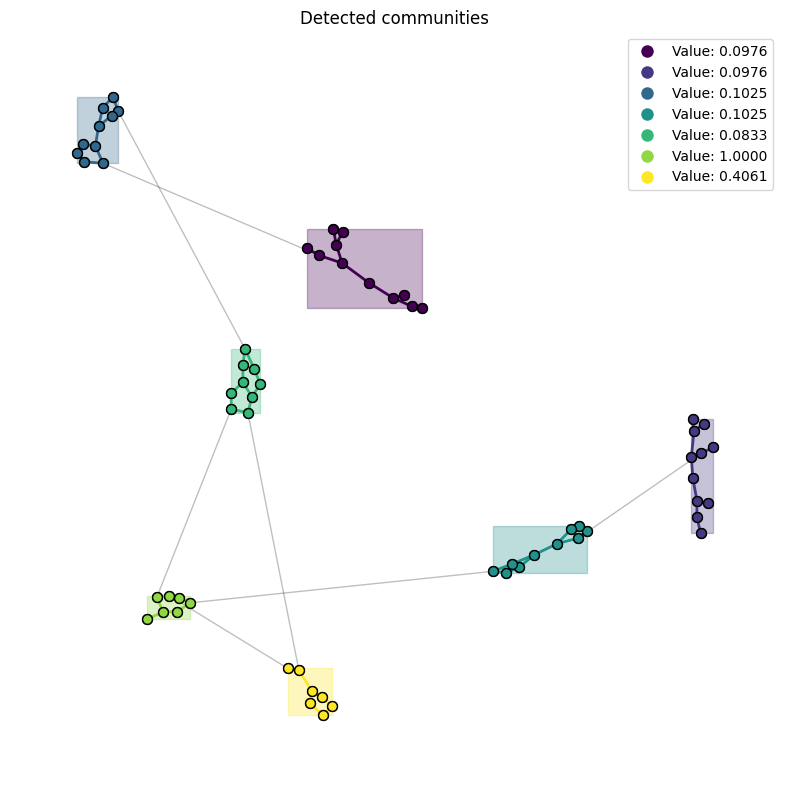

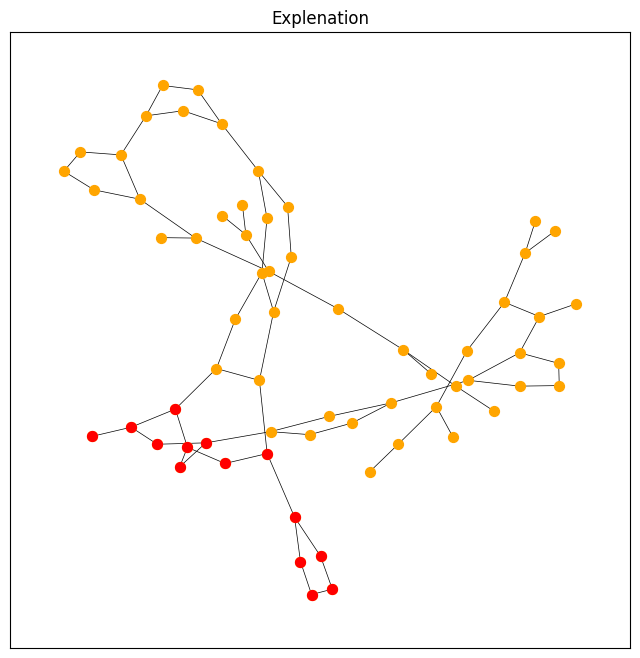

Tau 0.2699339815548488
1. Community [17, 18, 19, 20, 21, 22, 23] (7 nodes) - Probability: 1.0000
2. Community [24, 25, 26, 27, 28, 29, 30] (7 nodes) - Probability: 0.4061
3. Community [8, 9, 10, 11, 12, 13, 14, 15, 16, 61] (10 nodes) - Probability: 0.1025
4. Community [37, 38, 39, 40, 41, 42, 43, 44, 45, 57] (10 nodes) - Probability: 0.1025
5. Community [46, 47, 48, 49, 50, 51, 52, 53, 54, 55, 56] (11 nodes) - Probability: 0.0976
6. Community [0, 1, 2, 3, 64, 4, 5, 6, 7, 62, 63] (11 nodes) - Probability: 0.0976
7. Community [32, 33, 34, 35, 36, 58, 59, 60, 31] (9 nodes) - Probability: 0.0833


In [3]:
# Visualize GECo explanation for a single molecule from the Test Set of TASK X = Halogens

import torch
import matplotlib.pyplot as plt
from geco_explainer import GECo

# Import necessary modules from the project
from dataset import XAIMolecularDataset
from train_model import get_model
from torch.utils.data import Subset

# Define device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Load the trained model and its arguments
# The model was saved as model_GIN_X.pt
model_path = 'model_GIN_X.pt'
loaded = torch.load(model_path, map_location=device, weights_only=False)
loaded_args = loaded["args"]

# Initialize the dataset
dataset = XAIMolecularDataset("data", loaded_args["task"], explanations=True)
train_idxs, val_idxs, test_idxs = dataset.get_splits(loaded_args["split"], old=True)
dataset_test = Subset(dataset, test_idxs)

# Re-create the model instance and load its state dictionary
model = get_model(**loaded["model_args"]).to(device)
model.load_state_dict(loaded["state_dict"])

# model set to evaluation mode
model.eval()

# Selection of a molecule index from the test set to visualize
indice_molecola = 10
graph = dataset_test[indice_molecola].to(device)

# Initiliazation of GECo
geco = GECo(device, model)

# Calculate the prediction using our "safe" method that handles both GIN and GAT (with or without edge_attr)
batch = torch.zeros(graph.x.shape[0], dtype=torch.long).to(device)
try:
    out = model(graph.x, graph.edge_index, batch=batch)
except TypeError:
    out = model(graph.x, graph.edge_index, graph.edge_attr, batch)

target_class = out.argmax(dim=-1).item()
print(f"\nMolecule Analysis #{indice_molecola}")
print(f"Predicted Class from GAT: {target_class} (0 = Non-Halogen, 1 = Halogen)")

# Visualization of the explanation using GECo
print("Visualization...")
try:
    # visualize=True
    comunita = geco.explain(graph, target_class, visualize=True, verbose=True)
except Exception as e:
    print(f"Error: {e}")

# show the plot
plt.show()

### CausGNN:

In [ ]:
# Extract CausGNN explanations on TASK X = Halogens

!python extract_explanations.py --model_path model_GIN_X.pt --save_path expl_CausGNN_GIN_X.pt --explainer_type CausGNN --explanation_type phenomenon --node_mask_type object --edge_mask_type none

Namespace(seed=123, trials=1, save_path='expl_CausGNN_GIN_X.pt', batch_size=32, model_path='model_GIN_X.pt', explainer_type='CausGNN', explanation_type='phenomenon', node_mask_type='object', edge_mask_type=None, lr=0.001, epochs=200, n_samples=5, perturb='zero', save_all=False)
  2%|▌                                    | 769/50000 [00:00<00:18, 2617.36it/s][13:39:14] Explicit valence for atom # 1 P, 7, is greater than permitted
[13:39:14] ERROR: Could not sanitize molecule ending on line 117608
[13:39:14] ERROR: Explicit valence for atom # 1 P, 7, is greater than permitted
100%|███████████████████████████████████| 50000/50000 [00:17<00:00, 2857.93it/s]

[INFO] Avvio estrazione CausGNN (Prob-Drop approach)
100%|███████████████████████████████████████| 4999/4999 [03:58<00:00, 20.97it/s]
Finished with 4999/4999 explanations
Saved to expl_CausGNN_GIN_X.pt


In [ ]:
# Evaluate CausGNN explanations for GIN on TASK X = Halogens with IQR and AUROC (nodes)

!python evaluate_explanations.py --explanations_path expl_CausGNN_GIN_X.pt --mask_to_eval node --save_path results_CausGNN_GIN_X.pt

Namespace(seed=123, save_path='results_CausGNN_GIN_X.pt', explanations_path='expl_CausGNN_GIN_X.pt', mask_to_eval='node')
  2%|▋                                    | 912/50000 [00:00<00:39, 1244.70it/s][13:43:37] Explicit valence for atom # 1 P, 7, is greater than permitted
[13:43:37] ERROR: Could not sanitize molecule ending on line 117608
[13:43:37] ERROR: Explicit valence for atom # 1 P, 7, is greater than permitted
100%|███████████████████████████████████| 50000/50000 [00:21<00:00, 2347.30it/s]
Task: X Eval metric: roc_auc_score
100%|█████████████████████████████████████| 4999/4999 [00:01<00:00, 3243.86it/s]
Non empty: 0.5645129025805161 | Avg: 0.7894
Empty: 0.4354870974194839 | Avg: 0.0808
Saved to results_CausGNN_GIN_X.pt


### Integrated Gradients

In [ ]:
# Extract Integrated Gradients explanations for GIN on TASK X = Halogens
!python extract_explanations.py --model_path model_GIN_X.pt --save_path expl_IG_GIN_X.pt --explainer_type IntegratedGradients --explanation_type phenomenon --node_mask_type attributes --edge_mask_type none

Namespace(seed=123, trials=1, save_path='expl_IG_GIN_X.pt', batch_size=32, model_path='model_GIN_X.pt', explainer_type='IntegratedGradients', explanation_type='phenomenon', node_mask_type='attributes', edge_mask_type=None, lr=0.001, epochs=200, n_samples=5, perturb='zero', save_all=False)
  2%|▋                                    | 949/50000 [00:00<00:23, 2080.53it/s][13:44:04] Explicit valence for atom # 1 P, 7, is greater than permitted
[13:44:04] ERROR: Could not sanitize molecule ending on line 117608
[13:44:04] ERROR: Explicit valence for atom # 1 P, 7, is greater than permitted
100%|███████████████████████████████████| 50000/50000 [00:18<00:00, 2728.20it/s]

[INFO] Avvio estrazione Integrated Gradients (tramite Captum)
100%|██████████████████████████████████████| 4999/4999 [00:38<00:00, 128.32it/s]
Finished with 4999/4999 explanations
Saved to expl_IG_GIN_X.pt


In [ ]:
# Evaluate Integrated Gradients explanations for GIN on TASK X = Halogens with IQR and AUROC
!python evaluate_explanations.py --explanations_path expl_IG_GIN_X.pt --mask_to_eval node --save_path results_IG_nodes_GIN_X.pt

Namespace(seed=123, save_path='results_IG_nodes_GIN_X.pt', explanations_path='expl_IG_GIN_X.pt', mask_to_eval='node')
  2%|▋                                    | 983/50000 [00:00<00:19, 2499.54it/s][13:45:09] Explicit valence for atom # 1 P, 7, is greater than permitted
[13:45:09] ERROR: Could not sanitize molecule ending on line 117608
[13:45:09] ERROR: Explicit valence for atom # 1 P, 7, is greater than permitted
100%|███████████████████████████████████| 50000/50000 [00:19<00:00, 2581.23it/s]
Task: X Eval metric: roc_auc_score
100%|█████████████████████████████████████| 4999/4999 [00:01<00:00, 3308.32it/s]
Non empty: 0.5645129025805161 | Avg: 1.0000
Empty: 0.4354870974194839 | Avg: 0.2379
Saved to results_IG_nodes_GIN_X.pt


# 2. TASK PAINS *Pan Assay Interference Compounds* (False Positives Detection):

### Training GIN on Task PAINS:

In [ ]:
# Train GIN on TASK PAINS

!python train_model.py --model_type GIN --task PAINS --split 0 --save_path model_GIN_PAINS.pt

### SALIENCY:

In [ ]:
# Extract Saliency explanations for GIN on TASK PAINS

!python extract_explanations.py --model_path model_GIN_PAINS.pt --save_path expl_Saliency_GIN_PAINS.pt --explainer_type Saliency --explanation_type phenomenon --node_mask_type attributes --edge_mask_type none

Namespace(seed=123, trials=1, save_path='expl_Saliency_GIN_PAINS.pt', batch_size=32, model_path='model_GIN_PAINS.pt', explainer_type='Saliency', explanation_type='phenomenon', node_mask_type='attributes', edge_mask_type=None, lr=0.001, epochs=200, n_samples=5, perturb='zero', save_all=False)
  2%|▋                                    | 993/50000 [00:00<00:32, 1522.14it/s][13:49:02] Explicit valence for atom # 1 P, 7, is greater than permitted
[13:49:02] ERROR: Could not sanitize molecule ending on line 117608
[13:49:02] ERROR: Explicit valence for atom # 1 P, 7, is greater than permitted
  0%|                                                   | 0/157 [00:00<?, ?it/s]/Users/lucaderuggiero/Desktop/Progetto_XAIC/xaic/lib/python3.11/site-packages/captum/attr/_core/saliency.py:129: UserWarning: Input Tensor 0 did not already require gradients, required_grads has been set automatically.
  gradient_mask = apply_gradient_requirements(inputs_tuple)
100%|█████████████████████████████████████████|

In [ ]:
# Evaluate Saliency explanations for GIN on TASK PAINS with IQR and AUROC

!python evaluate_explanations.py --explanations_path expl_Saliency_GIN_PAINS.pt --mask_to_eval node --save_path results_Saliency_GIN_PAINS.pt

Namespace(seed=123, save_path='results_Saliency_GIN_PAINS.pt', explanations_path='expl_Saliency_GIN_PAINS.pt', mask_to_eval='node')
  2%|▋                                    | 947/50000 [00:00<00:34, 1426.13it/s][13:49:43] Explicit valence for atom # 1 P, 7, is greater than permitted
[13:49:43] ERROR: Could not sanitize molecule ending on line 117608
[13:49:43] ERROR: Explicit valence for atom # 1 P, 7, is greater than permitted
100%|███████████████████████████████████| 50000/50000 [00:26<00:00, 1888.97it/s]
Task: PAINS Eval metric: roc_auc_score
100%|█████████████████████████████████████| 4999/4999 [00:01<00:00, 3807.33it/s]
Non empty: 0.32866573314662934 | Avg: 0.7416
Empty: 0.6713342668533707 | Avg: 0.4982
Saved to results_Saliency_GIN_PAINS.pt


### GNNExplainer:

In [ ]:
# Extract GNNExplainer explanations for GIN on TASK PAINS (nodes + edges)

!python extract_explanations.py --model_path model_GIN_PAINS.pt --save_path expl_GNNExplainer_GIN_PAINS_with_edges.pt --explainer_type GNNExplainer --explanation_type phenomenon --node_mask_type attributes --edge_mask_type object

Namespace(seed=123, trials=1, save_path='expl_GNNExplainer_GIN_PAINS_with_edges.pt', batch_size=32, model_path='model_GIN_PAINS.pt', explainer_type='GNNExplainer', explanation_type='phenomenon', node_mask_type='attributes', edge_mask_type='object', lr=0.001, epochs=200, n_samples=5, perturb='zero', save_all=False)
  2%|▋                                     | 873/50000 [00:00<00:54, 903.72it/s][13:50:16] Explicit valence for atom # 1 P, 7, is greater than permitted
[13:50:16] ERROR: Could not sanitize molecule ending on line 117608
[13:50:16] ERROR: Explicit valence for atom # 1 P, 7, is greater than permitted
100%|█████████████████████████████████████████| 157/157 [02:37<00:00,  1.00s/it]
Finished with 4999/4999 explanations
Saved to expl_GNNExplainer_GIN_PAINS_with_edges.pt


In [ ]:
# Evaluate GNNExplainer explanations for GIN on TASK PAINS with IQR and AUROC (nodes)

!python evaluate_explanations.py --explanations_path expl_GNNExplainer_GIN_PAINS_with_edges.pt --mask_to_eval node --save_path results_GNNExplainer_GIN_PAINS.pt

Namespace(seed=123, save_path='results_GNNExplainer_GIN_PAINS.pt', explanations_path='expl_GNNExplainer_GIN_PAINS_with_edges.pt', mask_to_eval='node')
  2%|▌                                    | 838/50000 [00:00<00:34, 1429.13it/s][13:53:27] Explicit valence for atom # 1 P, 7, is greater than permitted
[13:53:27] ERROR: Could not sanitize molecule ending on line 117608
[13:53:27] ERROR: Explicit valence for atom # 1 P, 7, is greater than permitted
100%|███████████████████████████████████| 50000/50000 [00:25<00:00, 1933.46it/s]
Task: PAINS Eval metric: roc_auc_score
100%|█████████████████████████████████████| 4999/4999 [00:01<00:00, 4222.14it/s]
Non empty: 0.32866573314662934 | Avg: 0.4905
Empty: 0.6713342668533707 | Avg: 0.7062
Saved to results_GNNExplainer_GIN_PAINS.pt


In [ ]:
# Evaluate GNNExplainer explanations for GIN on TASK PAINS with IQR and AUROC (edges)

!python evaluate_explanations.py --explanations_path expl_GNNExplainer_GIN_PAINS_with_edges.pt --mask_to_eval edge --save_path results_GNNExplainer_edges_GIN_PAINS.pt

Namespace(seed=123, save_path='results_GNNExplainer_edges_GIN_PAINS.pt', explanations_path='expl_GNNExplainer_GIN_PAINS_with_edges.pt', mask_to_eval='edge')
  2%|▋                                    | 906/50000 [00:00<00:48, 1022.33it/s][13:54:00] Explicit valence for atom # 1 P, 7, is greater than permitted
[13:54:00] ERROR: Could not sanitize molecule ending on line 117608
[13:54:00] ERROR: Explicit valence for atom # 1 P, 7, is greater than permitted
100%|███████████████████████████████████| 50000/50000 [00:24<00:00, 2038.32it/s]
Task: PAINS Eval metric: roc_auc_score
100%|█████████████████████████████████████| 4999/4999 [00:01<00:00, 4297.72it/s]
Non empty: 0.32866573314662934 | Avg: 0.5602
Empty: 0.6713342668533707 | Avg: 0.4625
Saved to results_GNNExplainer_edges_GIN_PAINS.pt


### ProtGNN + GIN:

In [ ]:
# Train ProtGNN (GIN) on TASK PAINS with clst=0.1 and sep=0.05, max_epochs=100, warm_epochs=30
!python train_protgnn.py --clst 0.1 --sep 0.05 --model_type GIN --task PAINS --split 0 --max_epochs 100 --warm_epochs 30 --save_path model_ProtGNN_PAINS_GIN.pt

### GECo Explainer:

In [ ]:
# Extract GECo explanations on TASK PAINS

!python extract_explanations.py --model_path model_GIN_PAINS.pt --save_path expl_GECo_GIN_PAINS.pt --explainer_type GECo --explanation_type phenomenon --node_mask_type object --edge_mask_type none

Namespace(seed=123, trials=1, save_path='expl_GECo_GIN_PAINS.pt', batch_size=32, model_path='model_GIN_PAINS.pt', explainer_type='GECo', explanation_type='phenomenon', node_mask_type='object', edge_mask_type=None, lr=0.001, epochs=200, n_samples=5, perturb='zero', save_all=False)
  2%|▋                                    | 853/50000 [00:00<00:43, 1125.34it/s][13:54:31] Explicit valence for atom # 1 P, 7, is greater than permitted
[13:54:31] ERROR: Could not sanitize molecule ending on line 117608
[13:54:31] ERROR: Explicit valence for atom # 1 P, 7, is greater than permitted
100%|███████████████████████████████████| 50000/50000 [00:24<00:00, 2059.07it/s]
Note: to be able to use all crisp methods, you need to install some additional packages:  {'graph_tool', 'bayanpy', 'wurlitzer', 'infomap', 'leidenalg'}
Note: to be able to use all crisp methods, you need to install some additional packages:  {'pyclustering', 'ASLPAw'}
Note: to be able to use all crisp methods, you need to install some

In [ ]:
# Evaluate GECo explanations for GIN on TASK PAINS with IQR and AUROC

!python evaluate_explanations.py --explanations_path expl_GECo_GIN_PAINS.pt --mask_to_eval node --save_path results_GECo_GIN_PAINS.pt

Namespace(seed=123, save_path='results_GECo_GIN_PAINS.pt', explanations_path='expl_GECo_GIN_PAINS.pt', mask_to_eval='node')
  2%|▋                                    | 866/50000 [00:00<00:33, 1484.02it/s][13:55:59] Explicit valence for atom # 1 P, 7, is greater than permitted
[13:55:59] ERROR: Could not sanitize molecule ending on line 117608
[13:55:59] ERROR: Explicit valence for atom # 1 P, 7, is greater than permitted
100%|███████████████████████████████████| 50000/50000 [00:24<00:00, 2012.36it/s]
Task: PAINS Eval metric: roc_auc_score
100%|█████████████████████████████████████| 4999/4999 [00:01<00:00, 4443.17it/s]
Non empty: 0.32866573314662934 | Avg: 0.5969
Empty: 0.6713342668533707 | Avg: 0.8501
Saved to results_GECo_GIN_PAINS.pt


  2%|▏         | 910/50000 [00:00<00:37, 1320.44it/s][17:47:54] Explicit valence for atom # 1 P, 7, is greater than permitted
[17:47:54] ERROR: Could not sanitize molecule ending on line 117608
[17:47:54] ERROR: Explicit valence for atom # 1 P, 7, is greater than permitted
100%|██████████| 50000/50000 [00:25<00:00, 1996.29it/s]



Molecule Analysis #10
Predicted Class from GAT: 1 (0 = Non-Halogen, 1 = Halogen)
Visualization...


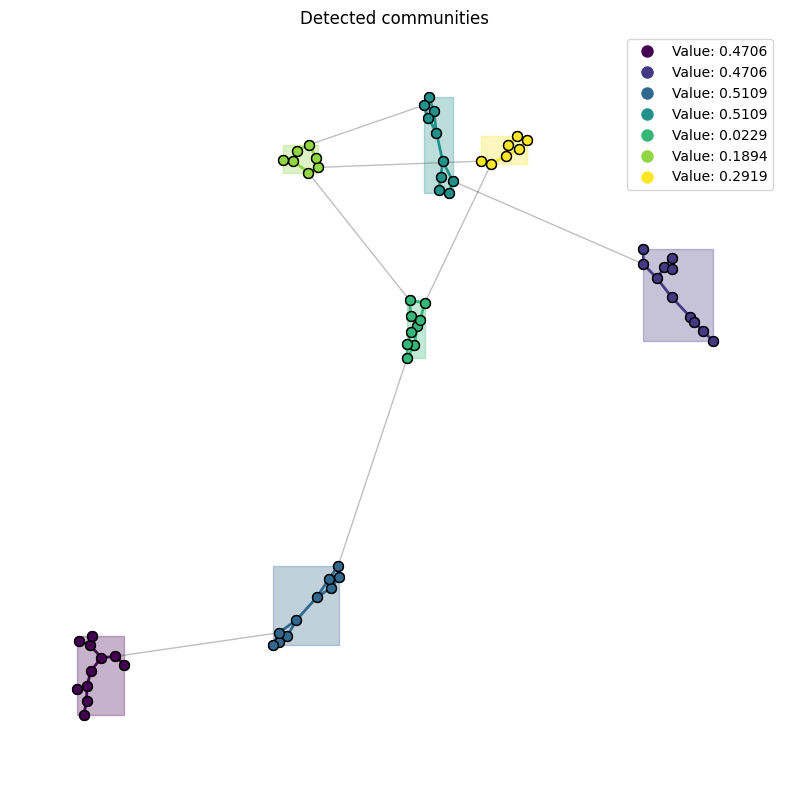

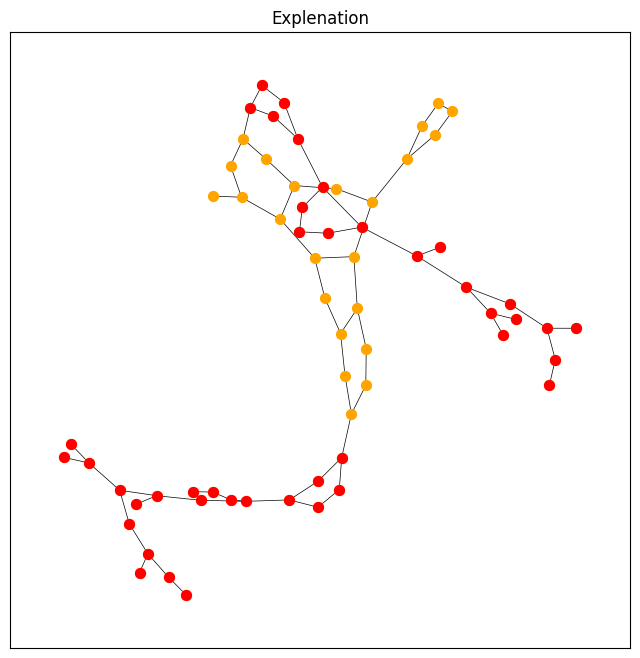

Tau 0.3524364610867841
1. Community [8, 9, 10, 11, 12, 13, 14, 15, 16, 61] (10 nodes) - Probability: 0.5109
2. Community [37, 38, 39, 40, 41, 42, 43, 44, 45, 57] (10 nodes) - Probability: 0.5109
3. Community [0, 1, 2, 3, 64, 4, 5, 6, 7, 62, 63] (11 nodes) - Probability: 0.4706
4. Community [46, 47, 48, 49, 50, 51, 52, 53, 54, 55, 56] (11 nodes) - Probability: 0.4706
5. Community [24, 25, 26, 27, 28, 29, 30] (7 nodes) - Probability: 0.2919
6. Community [17, 18, 19, 20, 21, 22, 23] (7 nodes) - Probability: 0.1894
7. Community [32, 33, 34, 35, 36, 58, 59, 60, 31] (9 nodes) - Probability: 0.0229


In [4]:
# Visualize GECo explanation for a single molecule from the Test Set of TASK PAINS

import torch
import matplotlib.pyplot as plt
from geco_explainer import GECo

# Import necessary modules from the project
from dataset import XAIMolecularDataset
from train_model import get_model
from torch.utils.data import Subset

# Define device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Load the trained model and its arguments
# The model was saved as model_GIN_X.pt
model_path = 'model_GIN_PAINS.pt'
loaded = torch.load(model_path, map_location=device, weights_only=False)
loaded_args = loaded["args"]

# Initialize the dataset
dataset = XAIMolecularDataset("data", loaded_args["task"], explanations=True)
train_idxs, val_idxs, test_idxs = dataset.get_splits(loaded_args["split"], old=True)
dataset_test = Subset(dataset, test_idxs)

# Re-create the model instance and load its state dictionary
model = get_model(**loaded["model_args"]).to(device)
model.load_state_dict(loaded["state_dict"])

# model set to evaluation mode
model.eval()

# Selection of a molecule index from the test set to visualize
indice_molecola = 10
graph = dataset_test[indice_molecola].to(device)

# Initiliazation of GECo
geco = GECo(device, model)

# Calculate the prediction using our "safe" method that handles both GIN and GAT (with or without edge_attr)
batch = torch.zeros(graph.x.shape[0], dtype=torch.long).to(device)
try:
    out = model(graph.x, graph.edge_index, batch=batch)
except TypeError:
    out = model(graph.x, graph.edge_index, graph.edge_attr, batch)

target_class = out.argmax(dim=-1).item()
print(f"\nMolecule Analysis #{indice_molecola}")
print(f"Predicted Class from GAT: {target_class} (0 = Non-Halogen, 1 = Halogen)")

# Visualization of the explanation using GECo
print("Visualization...")
try:
    # visualize=True
    comunita = geco.explain(graph, target_class, visualize=True, verbose=True)
except Exception as e:
    print(f"Error: {e}")

# show the plot
plt.show()

### CausGNN:

In [ ]:
# Extract CausGNN explanations on TASK PAINS (nodes + edges)

!python extract_explanations.py --model_path model_GIN_PAINS.pt --save_path expl_CausGNN_GIN_PAINS.pt --explainer_type CausGNN --explanation_type phenomenon --node_mask_type object --edge_mask_type object

Namespace(seed=123, trials=1, save_path='expl_CausGNN_GIN_PAINS.pt', batch_size=32, model_path='model_GIN_PAINS.pt', explainer_type='CausGNN', explanation_type='phenomenon', node_mask_type='object', edge_mask_type='object', lr=0.001, epochs=200, n_samples=5, perturb='zero', save_all=False)
  2%|▋                                    | 913/50000 [00:00<00:33, 1478.69it/s][13:56:58] Explicit valence for atom # 1 P, 7, is greater than permitted
[13:56:58] ERROR: Could not sanitize molecule ending on line 117608
[13:56:58] ERROR: Explicit valence for atom # 1 P, 7, is greater than permitted
100%|███████████████████████████████████| 50000/50000 [00:24<00:00, 2049.34it/s]

[INFO] Avvio estrazione CausGNN (Prob-Drop approach)
100%|███████████████████████████████████████| 4999/4999 [03:54<00:00, 21.35it/s]
Finished with 4999/4999 explanations
Saved to expl_CausGNN_GIN_PAINS.pt


In [ ]:
# Evaluate CausGNN explanations for GIN on TASK PAINS with IQR and AUROC (nodes)

!python evaluate_explanations.py --explanations_path expl_CausGNN_GIN_PAINS.pt --mask_to_eval node --save_path results_CausGNN_GIN_PAINS.pt

Namespace(seed=123, save_path='results_CausGNN_GIN_PAINS.pt', explanations_path='expl_CausGNN_GIN_PAINS.pt', mask_to_eval='node')
  2%|▋                                    | 960/50000 [00:00<00:33, 1485.37it/s][14:01:25] Explicit valence for atom # 1 P, 7, is greater than permitted
[14:01:25] ERROR: Could not sanitize molecule ending on line 117608
[14:01:25] ERROR: Explicit valence for atom # 1 P, 7, is greater than permitted
100%|███████████████████████████████████| 50000/50000 [00:25<00:00, 1948.08it/s]
Task: PAINS Eval metric: roc_auc_score
100%|█████████████████████████████████████| 4999/4999 [00:01<00:00, 4273.08it/s]
Non empty: 0.32866573314662934 | Avg: 0.8315
Empty: 0.6713342668533707 | Avg: 0.1022
Saved to results_CausGNN_GIN_PAINS.pt


In [ ]:
# Evaluate CausGNN explanations for GIN on TASK PAINS with IQR and AUROC (edges)

!python evaluate_explanations.py --explanations_path expl_CausGNN_GIN_PAINS.pt --mask_to_eval edge --save_path results_CausGNN_edges_GIN_PAINS.pt

Namespace(seed=123, save_path='results_CausGNN_edges_GIN_PAINS.pt', explanations_path='expl_CausGNN_GIN_PAINS.pt', mask_to_eval='edge')
  2%|▋                                    | 938/50000 [00:00<00:39, 1253.07it/s][14:01:59] Explicit valence for atom # 1 P, 7, is greater than permitted
[14:01:59] ERROR: Could not sanitize molecule ending on line 117608
[14:01:59] ERROR: Explicit valence for atom # 1 P, 7, is greater than permitted
100%|███████████████████████████████████| 50000/50000 [00:23<00:00, 2124.97it/s]
Task: PAINS Eval metric: roc_auc_score
100%|█████████████████████████████████████| 4999/4999 [00:01<00:00, 4423.02it/s]
Non empty: 0.32866573314662934 | Avg: 0.7916
Empty: 0.6713342668533707 | Avg: 0.0542
Saved to results_CausGNN_edges_GIN_PAINS.pt


### Integrated Gradients

In [ ]:
# Extract Integrated Gradients explanations for GIN on TASK PAINS (nodes)
!python extract_explanations.py --model_path model_GIN_PAINS.pt --save_path expl_IG_GIN_PAINS.pt --explainer_type IntegratedGradients --explanation_type phenomenon --node_mask_type attributes --edge_mask_type none

Namespace(seed=123, trials=1, save_path='expl_IG_GIN_PAINS.pt', batch_size=32, model_path='model_GIN_PAINS.pt', explainer_type='IntegratedGradients', explanation_type='phenomenon', node_mask_type='attributes', edge_mask_type=None, lr=0.001, epochs=200, n_samples=5, perturb='zero', save_all=False)
  2%|▋                                    | 894/50000 [00:00<00:47, 1038.35it/s][14:02:28] Explicit valence for atom # 1 P, 7, is greater than permitted
[14:02:28] ERROR: Could not sanitize molecule ending on line 117608
[14:02:28] ERROR: Explicit valence for atom # 1 P, 7, is greater than permitted
100%|███████████████████████████████████| 50000/50000 [00:23<00:00, 2135.31it/s]

[INFO] Avvio estrazione Integrated Gradients (tramite Captum)
100%|██████████████████████████████████████| 4999/4999 [00:38<00:00, 130.81it/s]
Finished with 4999/4999 explanations
Saved to expl_IG_GIN_PAINS.pt


In [ ]:
# Evaluate Integrated Gradients explanations for GIN on TASK PAINS with IQR and AUROC (nodes)
!python evaluate_explanations.py --explanations_path expl_IG_GIN_PAINS.pt --mask_to_eval node --save_path results_IG_nodes_GIN_PAINS.pt

Namespace(seed=123, save_path='results_IG_nodes_GIN_PAINS.pt', explanations_path='expl_IG_GIN_PAINS.pt', mask_to_eval='node')
  2%|▌                                    | 833/50000 [00:00<00:34, 1420.14it/s][14:03:39] Explicit valence for atom # 1 P, 7, is greater than permitted
[14:03:39] ERROR: Could not sanitize molecule ending on line 117608
[14:03:39] ERROR: Explicit valence for atom # 1 P, 7, is greater than permitted
100%|███████████████████████████████████| 50000/50000 [00:24<00:00, 2009.73it/s]
Task: PAINS Eval metric: roc_auc_score
100%|█████████████████████████████████████| 4999/4999 [00:01<00:00, 4410.53it/s]
Non empty: 0.32866573314662934 | Avg: 0.6221
Empty: 0.6713342668533707 | Avg: 0.1564
Saved to results_IG_nodes_GIN_PAINS.pt


# Result Visualization:

### How do we visualize them?

We used RDKit:

- Saliency & Integrated Gradients (IG) looking at the heatmap on the nodes
- GECo & CausGNN looking at the subgraphs
- GNNExplainer looking at the heatmap on the edges/nodes depending from the TASK

### Function to visualize the results:

In [31]:
import pandas as pd
import numpy as np
import torch
import matplotlib
from rdkit import Chem
from rdkit.Chem.Draw import rdMolDraw2D
from IPython.display import SVG, display

df_molecole = pd.read_csv('data/data.csv')


def _resolve_smiles(data, indice_molecola=None, df_molecole=None):
    if hasattr(data, "smiles"):
        smiles = data.smiles
        if isinstance(smiles, list):
            smiles = smiles[0]
        return smiles

    if df_molecole is None:
        raise ValueError(
            "Impossibile trovare gli SMILES: il grafo salvato non contiene `smiles` e non e' stato passato `df_molecole`."
        )
    if indice_molecola is None:
        raise ValueError("Serve `indice_molecola` quando si usa `df_molecole`.")

    row = df_molecole.iloc[indice_molecola]
    for col in ("smiles", "SMILES"):
        if col in row.index:
            smiles = row[col]
            if isinstance(smiles, list):
                smiles = smiles[0]
            return smiles

    raise KeyError("Non trovo una colonna SMILES nel dataframe: attese `smiles` o `SMILES`.")


def disegna_spiegazione_xai(data, method="heatmap_nodi", df_molecole=None, indice_molecola=None, method_family=None):
    """
    Disegna una molecola evidenziando la spiegazione XAI.
    Supporta sia grafi con `smiles` salvato dentro `data`, sia il recupero da CSV.
    """
    if method_family is not None:
        method = method_family

    smiles = _resolve_smiles(data, indice_molecola=indice_molecola, df_molecole=df_molecole)
    mol = Chem.MolFromSmiles(smiles)
    if mol is None:
        print(f"Errore: impossibile generare la molecola dal SMILES: {smiles}")
        return

    Chem.rdDepictor.Compute2DCoords(mol)

    drawer = rdMolDraw2D.MolDraw2DSVG(450, 450)
    opts = drawer.drawOptions()
    opts.useBWAtomPalette()
    opts.padding = 0.1
    opts.clearBackground = False

    highlight_atoms = []
    highlight_atom_colors = {}
    highlight_bonds = []
    highlight_bond_colors = {}

    def normalizza_maschera(tensore_maschera):
        mask_np = tensore_maschera.detach().cpu().numpy()
        if mask_np.ndim > 1:
            mask_np = np.abs(mask_np).sum(axis=1)
        if mask_np.max() > 0:
            mask_np = (mask_np - mask_np.min()) / (mask_np.max() - mask_np.min() + 1e-8)
        return mask_np

    if method == "heatmap_nodi":
        if not hasattr(data, "node_mask") or data.node_mask is None:
            print("Errore: node_mask non trovata.")
            return

        mask = normalizza_maschera(data.node_mask)
        cmap = matplotlib.colormaps.get_cmap("Reds")
        num_atoms = mol.GetNumAtoms()
        for i, val in enumerate(mask[:num_atoms]):
            if val > 0.05:
                highlight_atoms.append(i)
                highlight_atom_colors[i] = cmap(val)[:3]

    elif method == "sottografo":
        if not hasattr(data, "node_mask") or data.node_mask is None:
            print("Errore: node_mask non trovata.")
            return

        mask = normalizza_maschera(data.node_mask)
        threshold = 0.5
        colore_solido = (1.0, 0.2, 0.2)
        num_atoms = mol.GetNumAtoms()

        for i, val in enumerate(mask[:num_atoms]):
            if val >= threshold:
                highlight_atoms.append(i)
                highlight_atom_colors[i] = colore_solido

        for bond in mol.GetBonds():
            if bond.GetBeginAtomIdx() in highlight_atoms and bond.GetEndAtomIdx() in highlight_atoms:
                highlight_bonds.append(bond.GetIdx())
                highlight_bond_colors[bond.GetIdx()] = colore_solido

    elif method == "heatmap_legami":
        if not hasattr(data, "edge_mask") or data.edge_mask is None:
            print("Errore: edge_mask non trovata per i legami.")
            return

        mask = normalizza_maschera(data.edge_mask)
        cmap = matplotlib.colormaps.get_cmap("Reds")
        edge_index = data.edge_index.detach().cpu().numpy()
        num_atoms = mol.GetNumAtoms()

        for i in range(edge_index.shape[1]):
            u, v = int(edge_index[0, i]), int(edge_index[1, i])
            if u < 0 or v < 0 or u >= num_atoms or v >= num_atoms:
                continue
            val = mask[i]
            if val > 0.05:
                bond = mol.GetBondBetweenAtoms(u, v)
                if bond is not None:
                    idx = bond.GetIdx()
                    highlight_bonds.append(idx)
                    highlight_bond_colors[idx] = cmap(val)[:3]

    drawer.DrawMolecule(
        mol,
        highlightAtoms=highlight_atoms,
        highlightAtomColors=highlight_atom_colors,
        highlightBonds=highlight_bonds,
        highlightBondColors=highlight_bond_colors,
    )
    drawer.FinishDrawing()
    svg = drawer.GetDrawingText()
    display(SVG(svg))


def disegna_spiegazione_xai_da_csv(data, indice_molecola, df_molecole, method_family="heatmap_nodi"):
    return disegna_spiegazione_xai(
        data,
        method_family=method_family,
        df_molecole=df_molecole,
        indice_molecola=indice_molecola,
    )

### Saliency, Integrated Gradients (IG) & GNNExplainer - heatmap on nodes

Visualizzazione: Saliency con TASK X e GIN


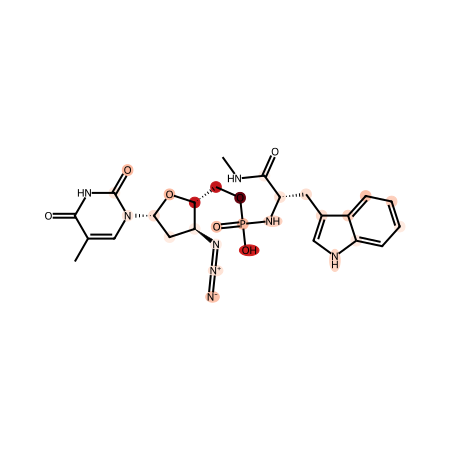

In [ ]:
# Upload results and explanations for Saliency on GIN + TASK X = Halogens
risultati_sal_GIN_X = torch.load('expl_Saliency_GIN_X.pt', weights_only = False)
spiegazioni_sal_GIN_X = risultati_sal_GIN_X['explanations']

# Take a single molecule explanation from the list of explanations for TASK X = Halogens and Saliency on GIN
molecola_test = spiegazioni_sal_GIN_X[10]

# Draw the explanation for the selected molecule using the function defined above, which retrieves the SMILES from the CSV and highlights the nodes according to the Saliency explanation.
print("Visualizzazione: Saliency con TASK X e GIN")
disegna_spiegazione_xai_da_csv(
    data=molecola_test, 
    indice_molecola=10, 
    df_molecole=df_molecole, 
    method_family="heatmap_nodi"
)

Visualizzazione: Saliency con TASK PAINS e GIN


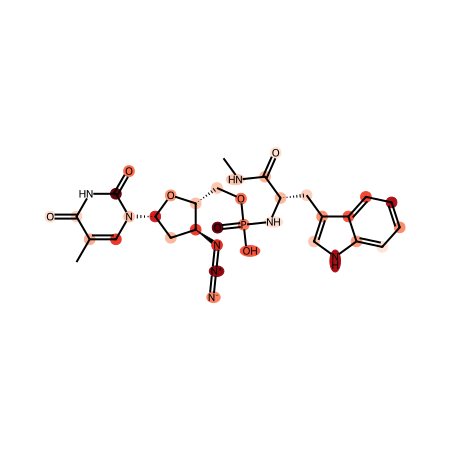

In [ ]:
# Upload results and explanations for Saliency on GIN + TASK PAINS
risultati_sal_GIN_PAINS = torch.load('expl_Saliency_GIN_PAINS.pt', weights_only=False)
spiegazioni_sal_GIN_PAINS = risultati_sal_GIN_PAINS['explanations']

# Take a single molecule explanation from the list of explanations for TASK PAINS and Saliency on GIN
molecola_test = spiegazioni_sal_GIN_PAINS[10]

# Draw the explanation for the selected molecule using the function defined above, which retrieves the SMILES from the CSV and highlights the nodes according to the Saliency explanation.
print("Visualizzazione: Saliency con TASK PAINS e GIN")
disegna_spiegazione_xai_da_csv(
    data=molecola_test,
    indice_molecola=10,
    df_molecole=df_molecole,
    method_family="heatmap_nodi"
)

Visualizzazione: Integrated Gradients con TASK X e GIN


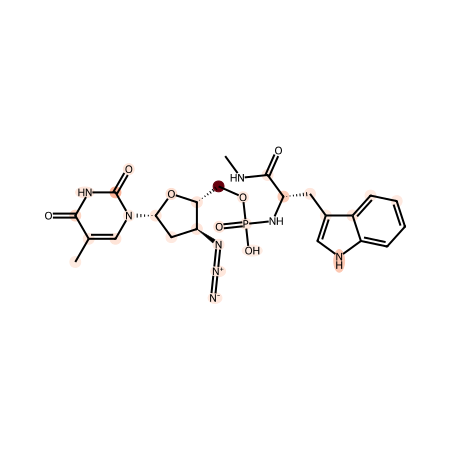

In [ ]:
# Upload results and explanations for Integrated Gradients on GAT + TASK X = Halogens
risultati_ig_GIN_X = torch.load('expl_IG_GIN_X.pt', weights_only=False)
spiegazioni_ig_GIN_X = risultati_ig_GIN_X['explanations']

# Take a single molecule explanation from the list of explanations for TASK X = Halogens and Integrated Gradients on GIN
molecola_test = spiegazioni_ig_GIN_X[10]

# Draw the explanation for the selected molecule using the function defined above, which retrieves the SMILES from the CSV and highlights the nodes according to the Integrated Gradients explanation.
print("Visualizzazione: Integrated Gradients con TASK X e GIN")
disegna_spiegazione_xai_da_csv(
    data=molecola_test,
    indice_molecola=10,
    df_molecole=df_molecole,
    method_family="heatmap_nodi"
)

Visualizzazione: Integrated Gradients con TASK PAINS e GIN


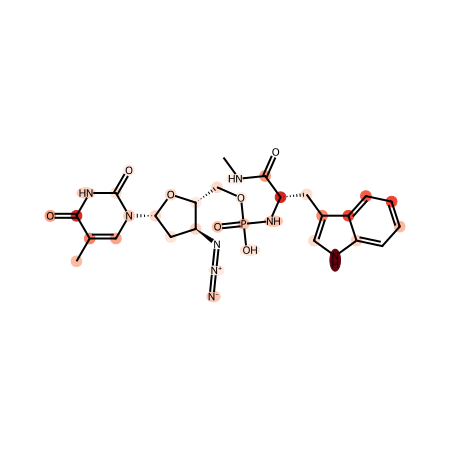

In [ ]:
# Upload results and explanations for Integrated Gradients on GIN + TASK PAINS
risultati_ig_GIN_PAINS = torch.load('expl_IG_GIN_PAINS.pt', weights_only=False)
spiegazioni_ig_GIN_PAINS = risultati_ig_GIN_PAINS['explanations']

# Take a single molecule explanation from the list of explanations for TASK PAINS and Integrated Gradients on GIN
molecola_test = spiegazioni_ig_GIN_PAINS[10]

# Draw the explanation for the selected molecule using the function defined above, which retrieves the SMILES from the CSV and highlights the nodes according to the Integrated Gradients explanation.
print("Visualizzazione: Integrated Gradients con TASK PAINS e GIN")
disegna_spiegazione_xai_da_csv(
    data=molecola_test,
    indice_molecola=10,
    df_molecole=df_molecole,
    method_family="heatmap_nodi"
)

Visualizzazione: GNNExplainer con TASK X e GIN


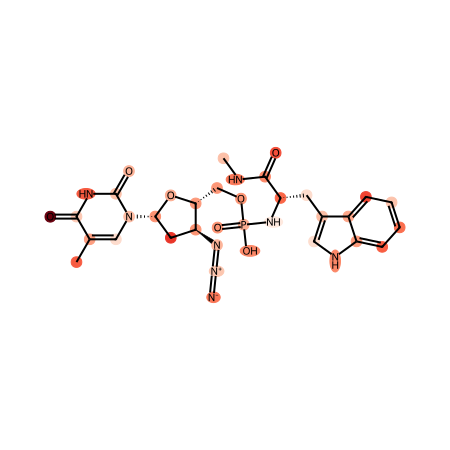

In [ ]:
# GNNExplainer - heatmap (nodes) on TASK X = Halogens

risultati_gnnexplainer_GIN_x = torch.load('expl_GNNExplainer_GIN_X.pt', weights_only=False)
spiegazioni_gnnexplainer_GIN_x = risultati_gnnexplainer_GIN_x['explanations']
molecola_test = spiegazioni_gnnexplainer_GIN_x[10]

print("Visualizzazione: GNNExplainer con TASK X e GIN")
disegna_spiegazione_xai_da_csv(
    data=molecola_test,
    indice_molecola=10,
    df_molecole=df_molecole,
    method_family="heatmap_nodi"
)


### GECo & CausGNN - subgraphs

Visualizzazione: GECo con TASK X e GIN


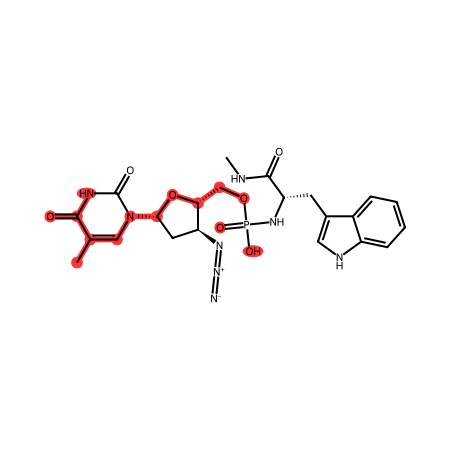

In [ ]:
# Upload results and explanations for GECo on GAT + TASK X = Halogens
risultati_geco_GIN_x = torch.load('expl_GECo_GIN_X.pt', weights_only=False)
spiegazioni_geco_GIN_x = risultati_geco_GIN_x['explanations']
molecola_test = spiegazioni_geco_GIN_x[10]

print("Visualizzazione: GECo con TASK X e GIN")
disegna_spiegazione_xai_da_csv(
    data=molecola_test,
    indice_molecola=10,
    df_molecole=df_molecole,
    method_family="sottografo"
)

Visualizzazione: GECo con TASK PAINS e GIN


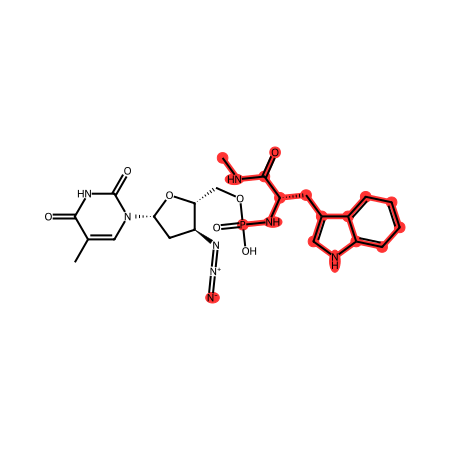

In [ ]:
# Upload results and explanations for GECo on GIN + TASK PAINS
risultati_geco_GIN_pains = torch.load('expl_GECo_GIN_PAINS.pt', weights_only=False)
spiegazioni_geco_GIN_pains = risultati_geco_GIN_pains['explanations']
molecola_test = spiegazioni_geco_GIN_pains[10]

print("Visualizzazione: GECo con TASK PAINS e GIN")
disegna_spiegazione_xai_da_csv(
    data=molecola_test,
    indice_molecola=10,
    df_molecole=df_molecole,
    method_family="sottografo"
)

Visualizzazione: CausGNN con TASK X e GIN


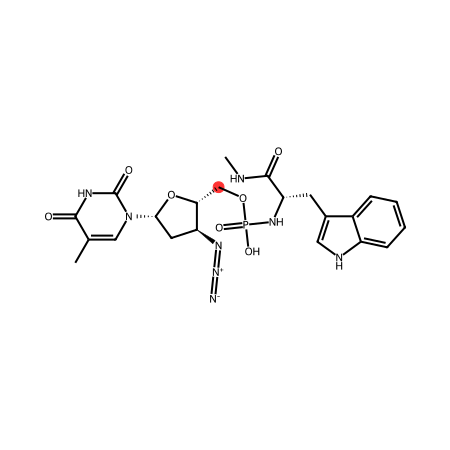

Visualizzazione: CausGNN con TASK PAINS e GIN


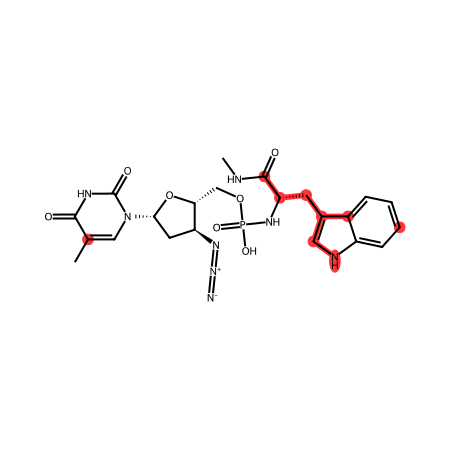

In [ ]:
# Upload results and explanations for CausGNN on GIN + TASK X = Halogens
risultati_causgnn_GIN_x = torch.load('expl_CausGNN_GIN_X.pt', weights_only=False)
spiegazioni_causgnn_GIN_x = risultati_causgnn_GIN_x['explanations']
molecola_test = spiegazioni_causgnn_GIN_x[10]

print("Visualizzazione: CausGNN con TASK X e GIN")
disegna_spiegazione_xai_da_csv(
    data=molecola_test,
    indice_molecola=10,
    df_molecole=df_molecole,
    method_family="sottografo"
)

# Upload results and explanations for CausGNN on GIN + TASK PAINS
risultati_causgnn_GIN_pains = torch.load('expl_CausGNN_GIN_PAINS.pt', weights_only=False)
spiegazioni_causgnn_GIN_pains = risultati_causgnn_GIN_pains['explanations']
molecola_test = spiegazioni_causgnn_GIN_pains[10]

print("Visualizzazione: CausGNN con TASK PAINS e GIN")
disegna_spiegazione_xai_da_csv(
    data=molecola_test,
    indice_molecola=10,
    df_molecole=df_molecole,
    method_family="sottografo"
)

### GNNExplainer - heatmap on the edges

Visualizzazione: GNNExplainer con TASK PAINS e GIN


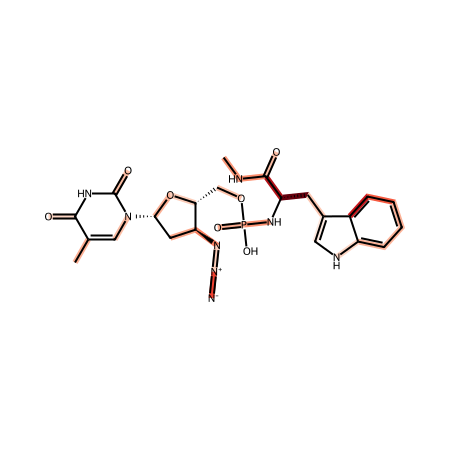

In [ ]:
# GNNExplainer - heatmap on edges for TASK PAINS + GIN
risultati_gnnexplainer_GIN_pains = torch.load('expl_GNNExplainer_GIN_PAINS_with_edges.pt', weights_only=False)
spiegazioni_gnnexplainer_GIN_pains = risultati_gnnexplainer_GIN_pains['explanations']
molecola_test = spiegazioni_gnnexplainer_GIN_pains[10]

print("Visualizzazione: GNNExplainer con TASK PAINS e GIN")
disegna_spiegazione_xai_da_csv(
    data=molecola_test,
    indice_molecola=10,
    df_molecole=df_molecole,
    method_family="heatmap_legami"
)